<a href="https://colab.research.google.com/github/newgirlsly/makeit/blob/main/PTN%20jogja%20ANAlyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1 — DATA UNDERSTANDING

In [1]:
# ==========================================
# DATA UNDERSTANDING
# ==========================================

import pandas as pd

# membaca dataset
df = pd.read_excel("YANG BENER.xlsx")

# membersihkan nama kolom
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# ==========================================
# INFORMASI DATASET
# ==========================================

print("=== UKURAN DATASET ===")
print(df.shape)

print("\n=== NAMA KOLOM ===")
print(df.columns)

print("\n=== TIPE DATA ===")
print(df.dtypes)

# ==========================================
# CEK MISSING VALUE
# ==========================================

print("\n=== MISSING VALUE ===")
print(df.isnull().sum())

# ==========================================
# CEK DUPLICATE
# ==========================================

print("\n=== DUPLICATE DATA ===")
print(df.duplicated().sum())

# ==========================================
# STATISTIK DESKRIPTIF
# ==========================================

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

=== UKURAN DATASET ===
(210, 8)

=== NAMA KOLOM ===
Index(['prodi', 'univ', 'peminat_2023', 'peminat_2024', 'daya_tampung_2024',
       'daya_tampung_2025', 'keketatan', 'pertumbuhan'],
      dtype='object')

=== TIPE DATA ===
prodi                 object
univ                  object
peminat_2023         float64
peminat_2024         float64
daya_tampung_2024    float64
daya_tampung_2025    float64
keketatan            float64
pertumbuhan          float64
dtype: object

=== MISSING VALUE ===
prodi                3
univ                 3
peminat_2023         3
peminat_2024         3
daya_tampung_2024    3
daya_tampung_2025    3
keketatan            3
pertumbuhan          3
dtype: int64

=== DUPLICATE DATA ===
2

=== STATISTIK DESKRIPTIF ===
       peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
count    207.000000    207.000000         207.000000         207.000000   
mean     604.536232    867.975845          41.077295          42.381643   
std      673.611047    868

## 2 — DISTRIBUSI DATA & OUTLIER

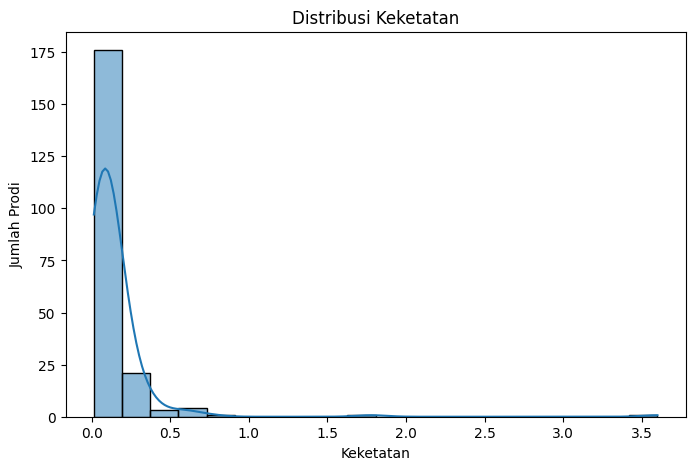

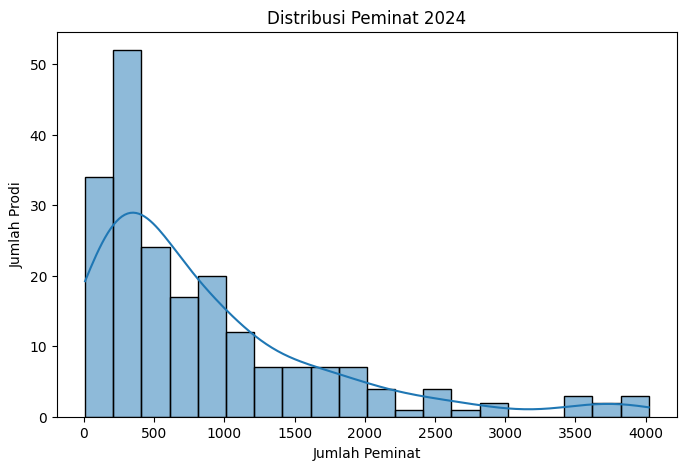

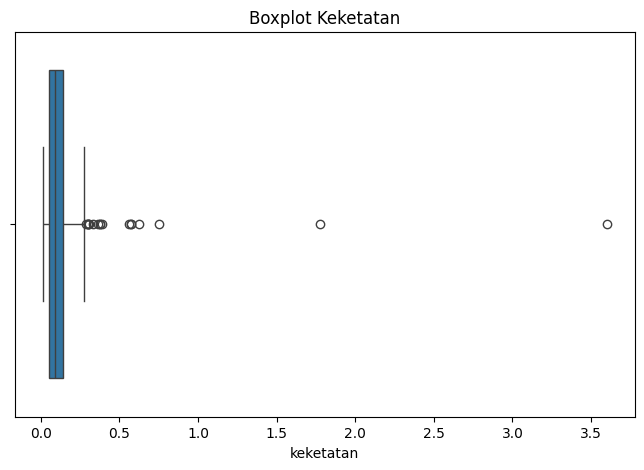

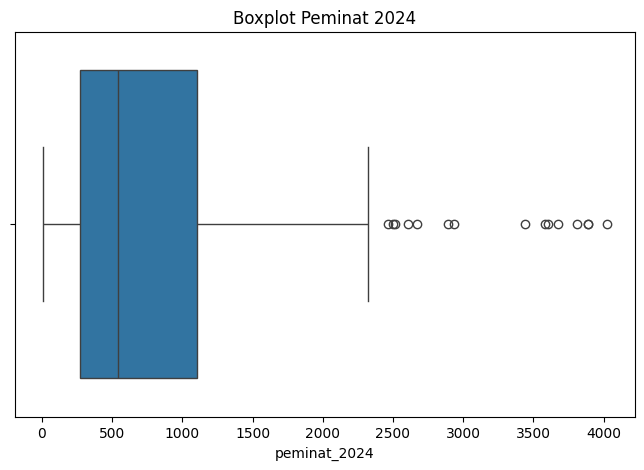

=== JUMLAH OUTLIER KEKETATAN ===
17

=== DATA OUTLIER ===
                                    prodi univ  keketatan  peminat_2024
188                          Teknik Kimia  UPN   3.600000         587.0
194                        Etnomusikologi  ISI   1.777778        1345.0
204                       Seni Pedalangan  ISI   0.750000           8.0
197                            Kriya Seni  ISI   0.623377         223.0
207                           Seni Teater  ISI   0.571429          49.0
202                        Seni Karawitan  ISI   0.571429          35.0
132                      Pendidikan Kriya  UNY   0.560000          36.0
201                       Penyajian Musik  ISI   0.387097         127.0
151      Pengobatan Tradisional Indonesia  UNY   0.378378         299.0
193                         Desain Produk  ISI   0.375839         322.0
199                      Pendidikan Musik  ISI   0.362205          77.0
196                       Konservasi Seni  ISI   0.333333          27.0
118   

In [2]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# DISTRIBUSI KEKETATAN
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df['keketatan'], bins=20, kde=True)

plt.title("Distribusi Keketatan")
plt.xlabel("Keketatan")
plt.ylabel("Jumlah Prodi")

plt.show()

# ==========================================
# DISTRIBUSI PEMINAT 2024
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df['peminat_2024'], bins=20, kde=True)

plt.title("Distribusi Peminat 2024")
plt.xlabel("Jumlah Peminat")
plt.ylabel("Jumlah Prodi")

plt.show()

# ==========================================
# BOXPLOT KEKETATAN
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(x=df['keketatan'])

plt.title("Boxplot Keketatan")

plt.show()

# ==========================================
# BOXPLOT PEMINAT 2024
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(x=df['peminat_2024'])

plt.title("Boxplot Peminat 2024")

plt.show()

# ==========================================
# DETEKSI OUTLIER DENGAN IQR
# ==========================================

Q1 = df['keketatan'].quantile(0.25)
Q3 = df['keketatan'].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier = df[
    (df['keketatan'] < batas_bawah) |
    (df['keketatan'] > batas_atas)
]

print("=== JUMLAH OUTLIER KEKETATAN ===")
print(outlier.shape[0])

print("\n=== DATA OUTLIER ===")

print(
    outlier[
        ['prodi', 'univ', 'keketatan', 'peminat_2024']
    ].sort_values('keketatan', ascending=False)
)

## 3 — ANALISIS KORELASI

=== KORELASI ANTAR VARIABEL ===
                   peminat_2023  peminat_2024  daya_tampung_2024  \
peminat_2023           1.000000      0.776308           0.542510   
peminat_2024           0.776308      1.000000           0.383765   
daya_tampung_2024      0.542510      0.383765           1.000000   
daya_tampung_2025      0.528269      0.364328           0.969636   
keketatan             -0.224375     -0.160560          -0.014640   
pertumbuhan           -0.144531      0.158753          -0.087886   

                   daya_tampung_2025  keketatan  pertumbuhan  
peminat_2023                0.528269  -0.224375    -0.144531  
peminat_2024                0.364328  -0.160560     0.158753  
daya_tampung_2024           0.969636  -0.014640    -0.087886  
daya_tampung_2025           1.000000   0.137550    -0.019314  
keketatan                   0.137550   1.000000     0.551913  
pertumbuhan                -0.019314   0.551913     1.000000  


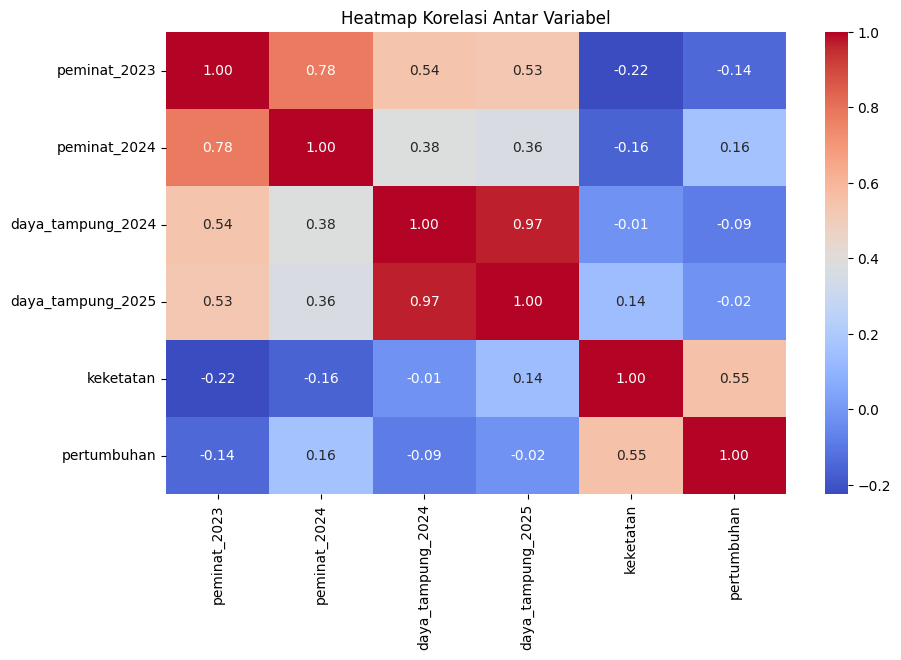

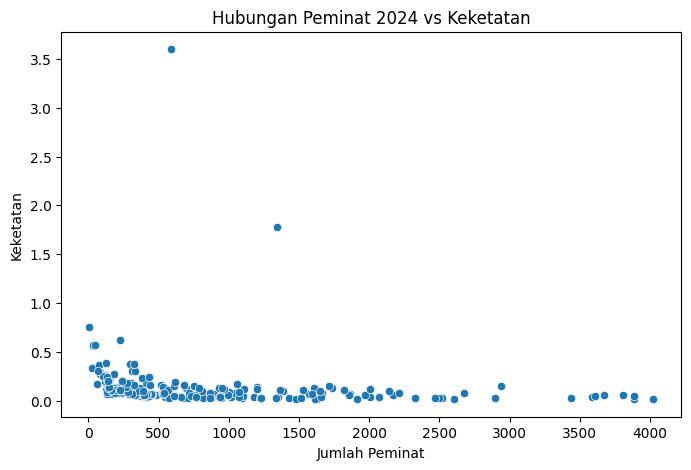

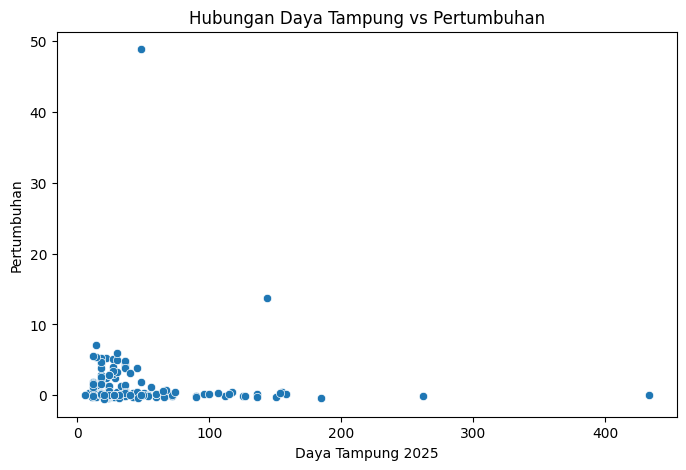

In [3]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PILIH VARIABEL NUMERIK
# ==========================================

kolom = [
    'peminat_2023',
    'peminat_2024',
    'daya_tampung_2024',
    'daya_tampung_2025',
    'keketatan',
    'pertumbuhan'
]

# ==========================================
# HITUNG KORELASI
# ==========================================

corr = df[kolom].corr()

# ==========================================
# TAMPILKAN ANGKA KORELASI
# ==========================================

print("=== KORELASI ANTAR VARIABEL ===")
print(corr)

# ==========================================
# HEATMAP KORELASI
# ==========================================

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Heatmap Korelasi Antar Variabel")

plt.show()

# ==========================================
# SCATTER PEMINAT vs KEKETATAN
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='peminat_2024',
    y='keketatan'
)

plt.title("Hubungan Peminat 2024 vs Keketatan")

plt.xlabel("Jumlah Peminat")

plt.ylabel("Keketatan")

plt.show()

# ==========================================
# SCATTER DAYA TAMPUNG vs PERTUMBUHAN
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='daya_tampung_2025',
    y='pertumbuhan'
)

plt.title("Hubungan Daya Tampung vs Pertumbuhan")

plt.xlabel("Daya Tampung 2025")

plt.ylabel("Pertumbuhan")

plt.show()

## 4 — PREPROCESSING & NORMALISASI

In [4]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

from sklearn.preprocessing import StandardScaler

# ==========================================
# PILIH VARIABEL UNTUK CLUSTERING
# ==========================================

kolom = [
    'peminat_2023',
    'peminat_2024',
    'daya_tampung_2024',
    'daya_tampung_2025',
    'keketatan',
    'pertumbuhan'
]

X = df[kolom]

# ==========================================
# CEK MISSING VALUE
# ==========================================

print("=== MISSING VALUE SEBELUM PREPROCESSING ===")
print(X.isnull().sum())

# ==========================================
# HANDLE MISSING VALUE
# ==========================================

X = X.fillna(X.median())

print("\n=== MISSING VALUE SETELAH PREPROCESSING ===")
print(X.isnull().sum())

# ==========================================
# NORMALISASI DATA
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# UBAH KE DATAFRAME AGAR MUDAH DIBACA
# ==========================================

X_scaled = pd.DataFrame(
    X_scaled,
    columns=kolom
)

# ==========================================
# HASIL NORMALISASI
# ==========================================

print("\n=== HASIL NORMALISASI ===")

print(X_scaled.head())

# ==========================================
# STATISTIK SETELAH NORMALISASI
# ==========================================

print("\n=== STATISTIK SETELAH NORMALISASI ===")

print(X_scaled.describe().round(2))

=== MISSING VALUE SEBELUM PREPROCESSING ===
peminat_2023         3
peminat_2024         3
daya_tampung_2024    3
daya_tampung_2025    3
keketatan            3
pertumbuhan          3
dtype: int64

=== MISSING VALUE SETELAH PREPROCESSING ===
peminat_2023         0
peminat_2024         0
daya_tampung_2024    0
daya_tampung_2025    0
keketatan            0
pertumbuhan          0
dtype: int64

=== HASIL NORMALISASI ===
   peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
0     -0.271058     -0.403601           0.614323           0.585331   
1      1.883759      1.325382           0.704775           0.675997   
2     -0.242607     -0.582541          -0.177136          -0.275990   
3     -0.483695     -0.601132          -0.244975          -0.275990   
4     -0.396843     -0.667364          -0.380654          -0.411988   

   keketatan  pertumbuhan  
0   0.071677    -0.213723  
1  -0.357850    -0.254067  
2  -0.254607    -0.321962  
3  -0.116598    -0.209427  
4  -0.243827   

## 5 — MENENTUKAN CLUSTER OPTIMAL

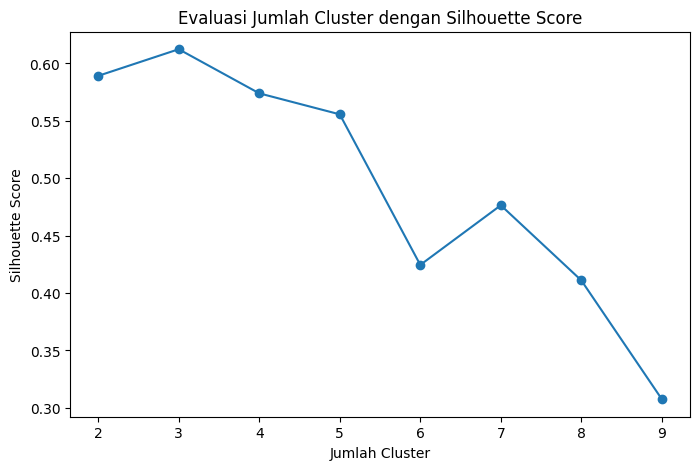

=== JUMLAH CLUSTER TERBAIK ===
3

=== NILAI SILHOUETTE TERBAIK ===
0.6124339898653116


In [5]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==========================================
# MENYIMPAN NILAI SILHOUETTE
# ==========================================

silhouette_scores = []

# range jumlah cluster
K = range(2, 10)

# ==========================================
# PERCOBAAN BERBAGAI JUMLAH CLUSTER
# ==========================================

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

# ==========================================
# VISUALISASI SILHOUETTE SCORE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    K,
    silhouette_scores,
    marker='o'
)

plt.title("Evaluasi Jumlah Cluster dengan Silhouette Score")

plt.xlabel("Jumlah Cluster")

plt.ylabel("Silhouette Score")

plt.show()

# ==========================================
# CLUSTER TERBAIK
# ==========================================

best_k = K[silhouette_scores.index(max(silhouette_scores))]

print("=== JUMLAH CLUSTER TERBAIK ===")
print(best_k)

print("\n=== NILAI SILHOUETTE TERBAIK ===")
print(max(silhouette_scores))

## 6 — PEMBENTUKAN CLUSTER

=== HASIL CLUSTERING ===
                              prodi univ  peminat_2024  keketatan  \
0                           Biologi  UGM         516.0   0.161905   
1                           Farmasi  UGM        2004.0   0.038731   
2               Geografi Lingkungan  UGM         362.0   0.068337   
3  Kartografi Dan Penginderaan Jauh  UGM         346.0   0.107914   
4               Pembangunan Wilayah  UGM         289.0   0.071429   
5                        Kedokteran  UGM        3889.0   0.014073   
6                  Ilmu Keperawatan  UGM        1178.0   0.034351   
7                              Gizi  UGM        1092.0   0.027675   
8                   Kedokteran Gigi  UGM        1350.0   0.037302   
9                  Kedokteran Hewan  UGM         789.0   0.059642   

   pertumbuhan  cluster  
0     0.228571        2  
1     0.077999        0  
2    -0.175399        2  
3     0.244604        2  
4    -0.139881        2  
5     0.032661        0  
6     0.124046        2  
7     0

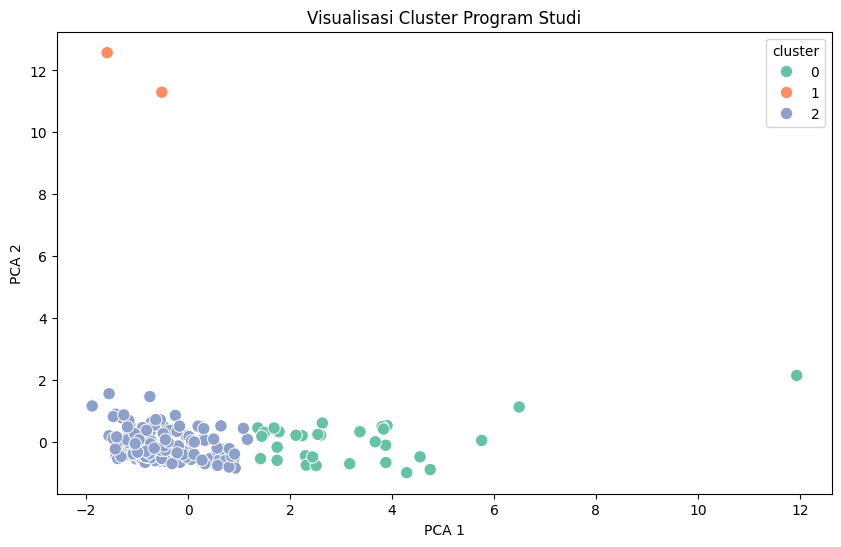

In [6]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ==========================================
# PEMBENTUKAN MODEL KMEANS
# ==========================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

# ==========================================
# MEMBENTUK CLUSTER
# ==========================================

df['cluster'] = kmeans.fit_predict(X_scaled)

# ==========================================
# HASIL CLUSTER
# ==========================================

print("=== HASIL CLUSTERING ===")

print(
    df[
        [
            'prodi',
            'univ',
            'peminat_2024',
            'keketatan',
            'pertumbuhan',
            'cluster'
        ]
    ].head(10)
)

# ==========================================
# JUMLAH DATA TIAP CLUSTER
# ==========================================

print("\n=== JUMLAH DATA TIAP CLUSTER ===")

print(df['cluster'].value_counts())

# ==========================================
# PCA UNTUK VISUALISASI
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# simpan ke dataframe
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

# ==========================================
# VARIANSI PCA
# ==========================================

print("\n=== EXPLAINED VARIANCE PCA ===")

print(pca.explained_variance_ratio_)

print("\n=== TOTAL INFORMASI PCA ===")

print(pca.explained_variance_ratio_.sum())

# ==========================================
# VISUALISASI CLUSTER
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='pca1',
    y='pca2',
    hue='cluster',
    palette='Set2',
    s=80
)

plt.title("Visualisasi Cluster Program Studi")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

## 7 — INTERPRETASI CLUSTER MENDALAM

=== UKURAN DATA ===
(210, 8)

=== MISSING VALUE ===
prodi                3
univ                 3
peminat_2023         3
peminat_2024         3
daya_tampung_2024    3
daya_tampung_2025    3
keketatan            3
pertumbuhan          3
dtype: int64

=== DUPLICATE ===
2

=== STATISTIK DESKRIPTIF ===
       peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
count    208.000000    208.000000         208.000000          208.00000   
mean     603.350962    866.418269          40.995192           42.31250   
std      672.199387    866.261691          44.510380           44.41475   
min        8.000000      8.000000           6.000000            6.00000   
25%      203.250000    272.750000          23.000000           24.00000   
50%      358.000000    544.000000          24.000000           28.00000   
75%      740.250000   1106.000000          42.000000           45.00000   
max     3837.000000   4022.000000         429.000000          433.00000   

        keketatan  pertu

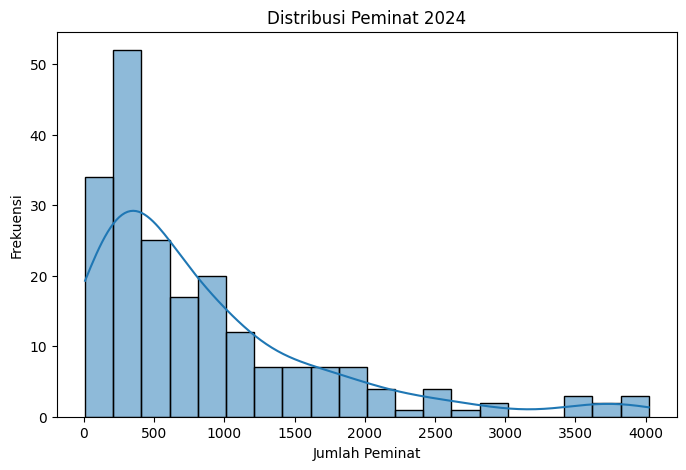

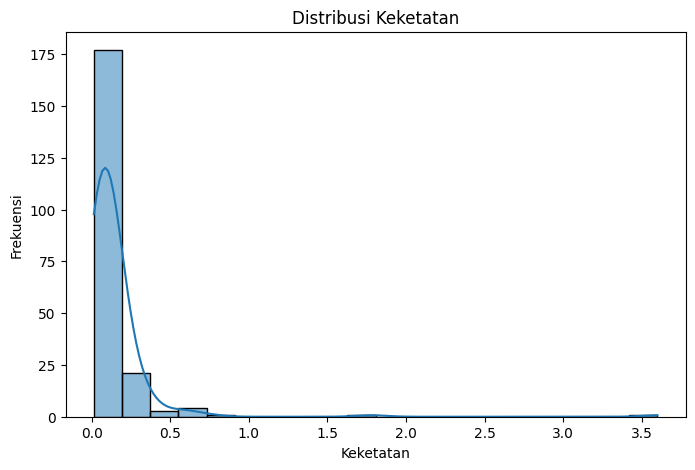

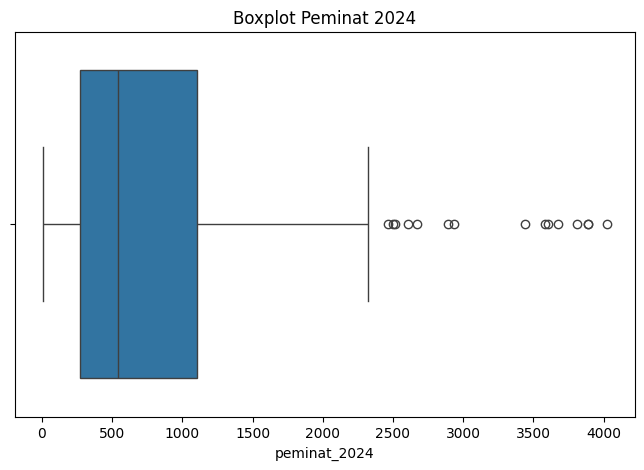

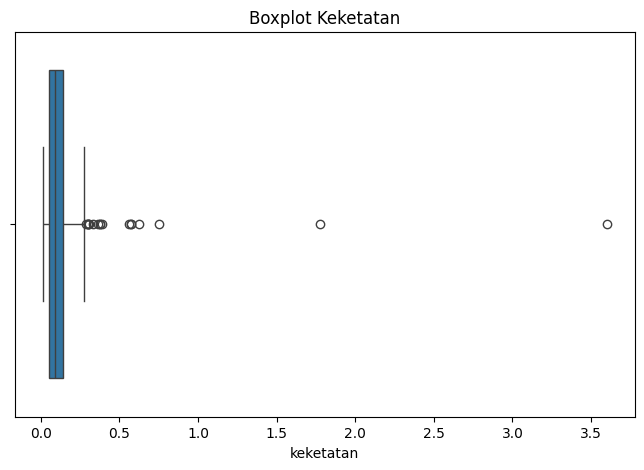


=== JUMLAH OUTLIER ===
17

=== DATA OUTLIER ===
                                    prodi univ  keketatan  peminat_2024
188                          Teknik Kimia  UPN   3.600000         587.0
194                        Etnomusikologi  ISI   1.777778        1345.0
204                       Seni Pedalangan  ISI   0.750000           8.0
197                            Kriya Seni  ISI   0.623377         223.0
207                           Seni Teater  ISI   0.571429          49.0
202                        Seni Karawitan  ISI   0.571429          35.0
132                      Pendidikan Kriya  UNY   0.560000          36.0
201                       Penyajian Musik  ISI   0.387097         127.0
151      Pengobatan Tradisional Indonesia  UNY   0.378378         299.0
193                         Desain Produk  ISI   0.375839         322.0
199                      Pendidikan Musik  ISI   0.362205          77.0
196                       Konservasi Seni  ISI   0.333333          27.0
118            

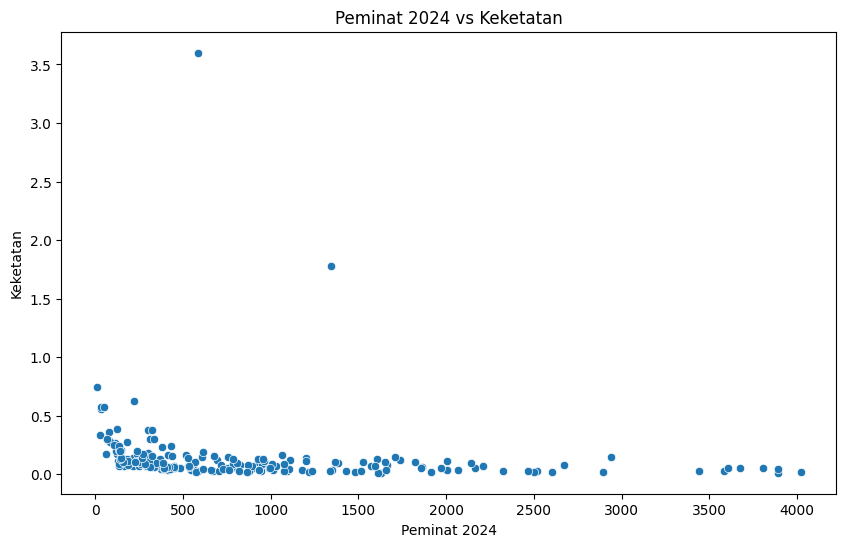


=== SKEWNESS ===
peminat_2024    1.753794
keketatan       9.376755
dtype: float64


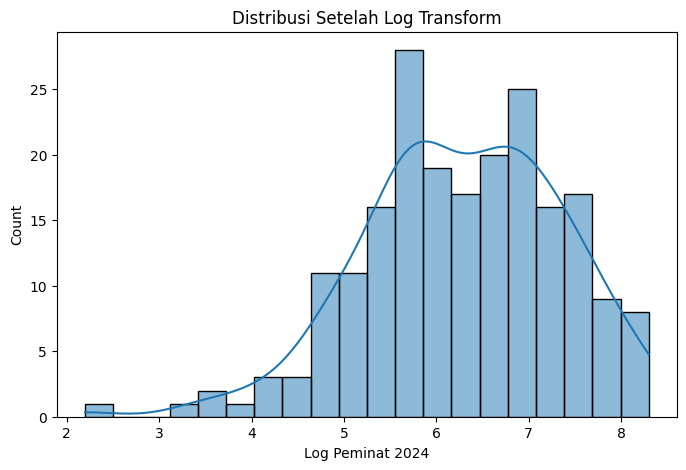

In [9]:
# ==========================================
# 2. DISTRIBUSI DATA & OUTLIER
# ==========================================

# IMPORT LIBRARY
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# BERSIHKAN NAMA KOLOM
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# ==========================================
# CEK INFO DASAR
# ==========================================
print("=== UKURAN DATA ===")
print(df.shape)

print("\n=== MISSING VALUE ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ===")
print(df.duplicated().sum())

# ==========================================
# HAPUS DUPLIKAT
# ==========================================
df = df.drop_duplicates()

# ==========================================
# HANDLE MISSING VALUE
# ==========================================
df = df.fillna(df.median(numeric_only=True))

# ==========================================
# STATISTIK DESKRIPTIF
# ==========================================
print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

# ==========================================
# HISTOGRAM PEMINAT 2024
# ==========================================
plt.figure(figsize=(8,5))
sns.histplot(df['peminat_2024'], bins=20, kde=True)

plt.title("Distribusi Peminat 2024")
plt.xlabel("Jumlah Peminat")
plt.ylabel("Frekuensi")

plt.show()

# ==========================================
# HISTOGRAM KEKETATAN
# ==========================================
plt.figure(figsize=(8,5))
sns.histplot(df['keketatan'], bins=20, kde=True)

plt.title("Distribusi Keketatan")
plt.xlabel("Keketatan")
plt.ylabel("Frekuensi")

plt.show()

# ==========================================
# BOXPLOT PEMINAT 2024
# ==========================================
plt.figure(figsize=(8,5))
sns.boxplot(x=df['peminat_2024'])

plt.title("Boxplot Peminat 2024")

plt.show()

# ==========================================
# BOXPLOT KEKETATAN
# ==========================================
plt.figure(figsize=(8,5))
sns.boxplot(x=df['keketatan'])

plt.title("Boxplot Keketatan")

plt.show()

# ==========================================
# DETEKSI OUTLIER DENGAN IQR
# ==========================================

Q1 = df['keketatan'].quantile(0.25)
Q3 = df['keketatan'].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier = df[
    (df['keketatan'] < batas_bawah) |
    (df['keketatan'] > batas_atas)
]

# ==========================================
# HASIL OUTLIER
# ==========================================
print("\n=== JUMLAH OUTLIER ===")
print(outlier.shape[0])

print("\n=== DATA OUTLIER ===")
print(
    outlier[
        ['prodi', 'univ', 'keketatan', 'peminat_2024']
    ].sort_values(
        by='keketatan',
        ascending=False
    )
)

# ==========================================
# VISUALISASI SCATTER OUTLIER
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='peminat_2024',
    y='keketatan'
)

plt.title("Peminat 2024 vs Keketatan")
plt.xlabel("Peminat 2024")
plt.ylabel("Keketatan")

plt.show()

# ==========================================
# CEK SKEWNESS
# ==========================================
print("\n=== SKEWNESS ===")
print(df[['peminat_2024', 'keketatan']].skew())

# ==========================================
# LOG TRANSFORMATION (OPSIONAL)
# ==========================================

df['log_peminat_2024'] = np.log1p(df['peminat_2024'])

plt.figure(figsize=(8,5))
sns.histplot(df['log_peminat_2024'], bins=20, kde=True)

plt.title("Distribusi Setelah Log Transform")
plt.xlabel("Log Peminat 2024")

plt.show()

UKURAN DATASET
(210, 8)

NAMA KOLOM
Index(['prodi', 'univ', 'peminat_2023', 'peminat_2024', 'daya_tampung_2024',
       'daya_tampung_2025', 'keketatan', 'pertumbuhan'],
      dtype='object')

TIPE DATA
prodi                 object
univ                  object
peminat_2023         float64
peminat_2024         float64
daya_tampung_2024    float64
daya_tampung_2025    float64
keketatan            float64
pertumbuhan          float64
dtype: object

MISSING VALUE
prodi                3
univ                 3
peminat_2023         3
peminat_2024         3
daya_tampung_2024    3
daya_tampung_2025    3
keketatan            3
pertumbuhan          3
dtype: int64

JUMLAH DUPLIKAT
2

STATISTIK DESKRIPTIF
       peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
count    208.000000    208.000000         208.000000          208.00000   
mean     603.350962    866.418269          40.995192           42.31250   
std      672.199387    866.261691          44.510380           44.41475  

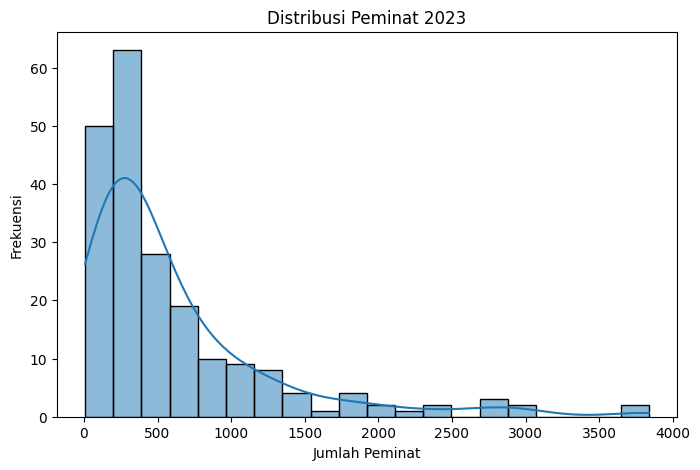

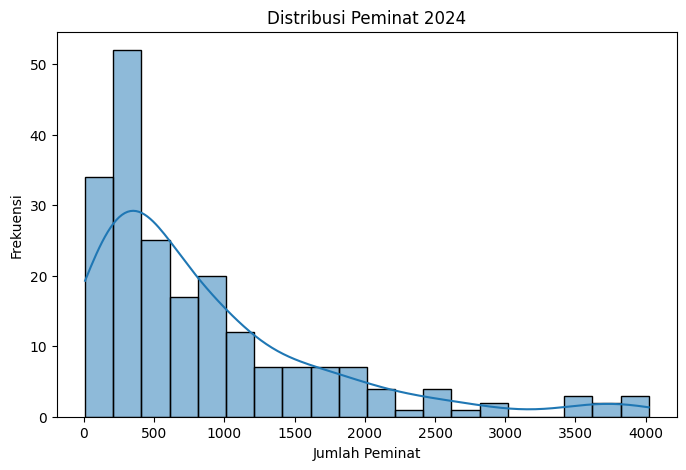

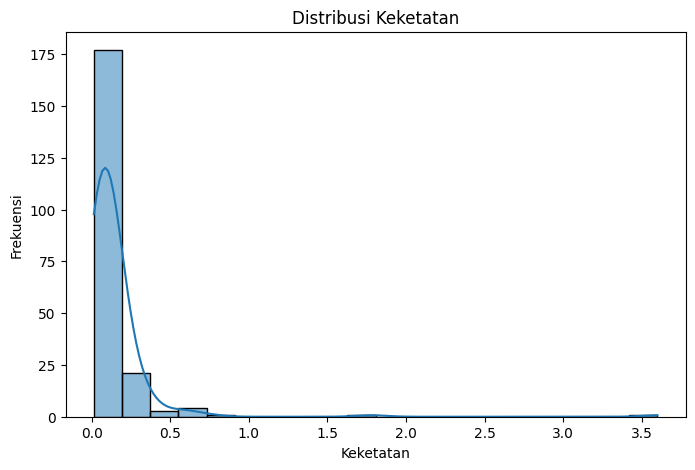

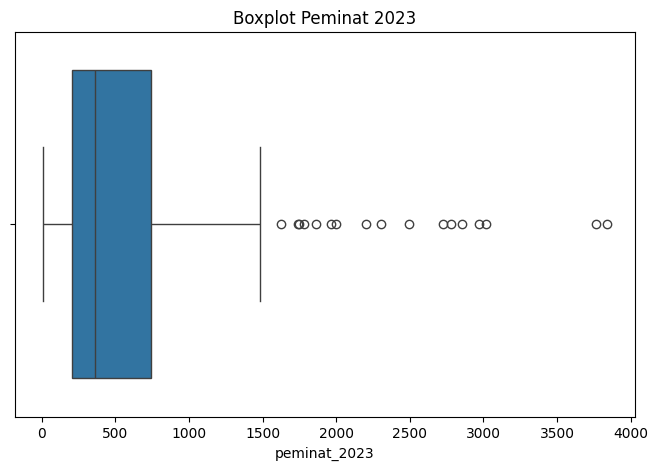

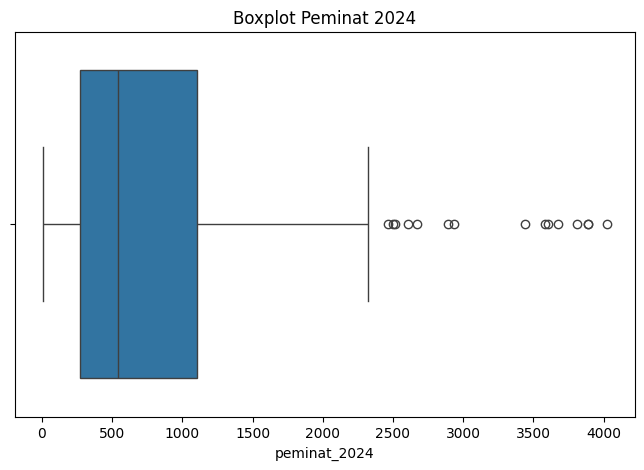

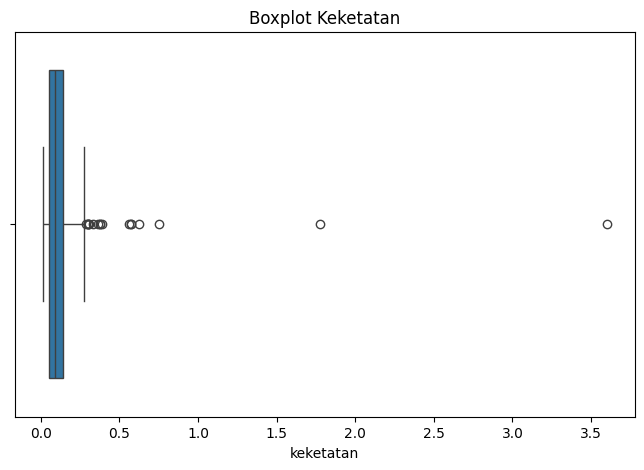


JUMLAH OUTLIER PEMINAT 2024
15

DATA OUTLIER PEMINAT 2024
                             prodi univ  peminat_2024
68                       Psikologi  UGM        4022.0
5                       Kedokteran  UGM        3889.0
93        Administrasi Perkantoran  UNY        3888.0
71   Manajemen Informasi Kesehatan  UGM        3808.0
191            Teknik Pertambangan  UPN        3673.0
87         Akuntansi Sektor Publik  UGM        3606.0
51                           Hukum  UGM        3584.0
106                      Manajemen  UNY        3438.0
179                      Manajemen  UPN        2938.0
153                      Psikologi  UNY        2894.0
107            Manajemen Pemasaran  UNY        2672.0
48                       Manajemen  UGM        2604.0
95                       Akuntansi  UNY        2517.0
102                Ilmu Komunikasi  UNY        2500.0
157                      Tata Boga  UNY        2466.0

JUMLAH OUTLIER KEKETATAN
17

DATA OUTLIER KEKETATAN
                        

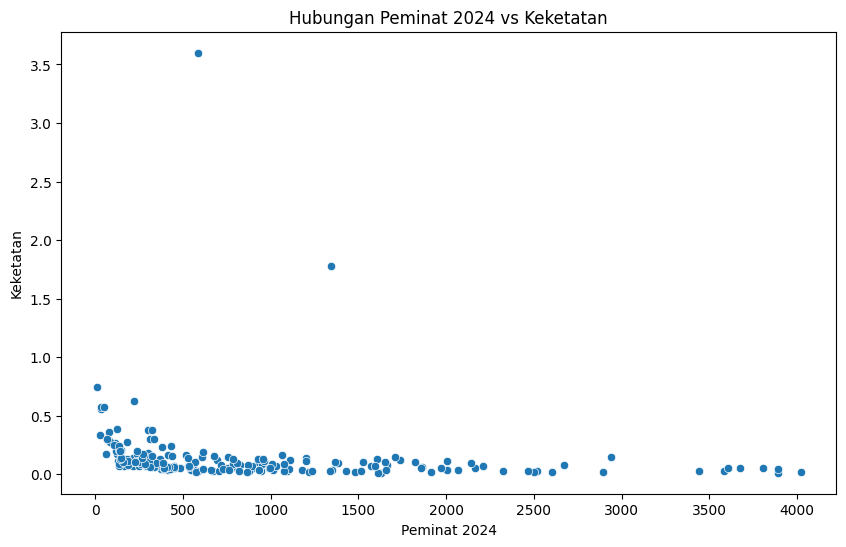

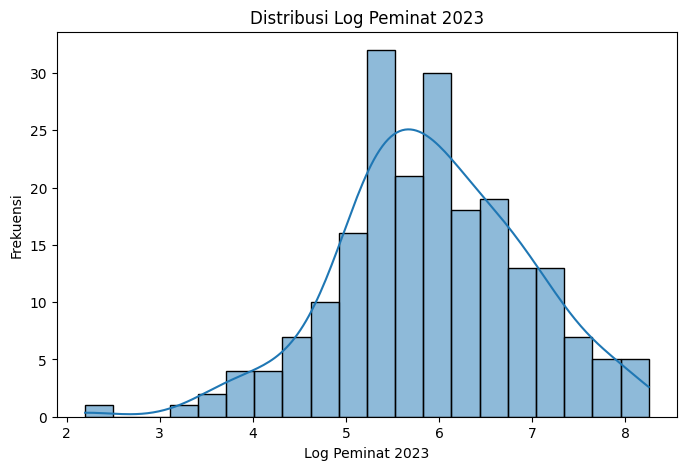

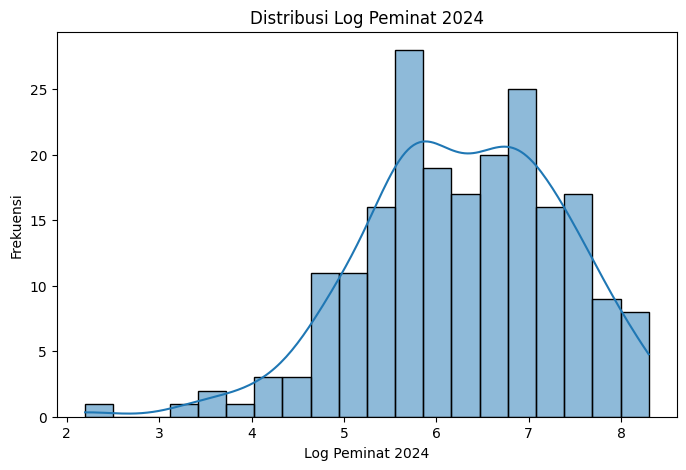


PERBANDINGAN SKEWNESS
Sebelum Log:
peminat_2023    2.408791
peminat_2024    1.753794
dtype: float64

Sesudah Log:
log_peminat_2023   -0.192242
log_peminat_2024   -0.441765
dtype: float64


In [11]:
# ==========================================
# ANALISIS DISTRIBUSI & OUTLIER LENGKAP
# ==========================================

# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# ==========================================
# MEMBERSIHKAN NAMA KOLOM
# ==========================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# ==========================================
# INFORMASI DATASET
# ==========================================
print("===================================")
print("UKURAN DATASET")
print("===================================")
print(df.shape)

print("\n===================================")
print("NAMA KOLOM")
print("===================================")
print(df.columns)

print("\n===================================")
print("TIPE DATA")
print("===================================")
print(df.dtypes)

# ==========================================
# CEK MISSING VALUE
# ==========================================
print("\n===================================")
print("MISSING VALUE")
print("===================================")
print(df.isnull().sum())

# ==========================================
# CEK DUPLIKAT
# ==========================================
print("\n===================================")
print("JUMLAH DUPLIKAT")
print("===================================")
print(df.duplicated().sum())

# ==========================================
# HAPUS DUPLIKAT
# ==========================================
df = df.drop_duplicates()

# ==========================================
# HANDLE MISSING VALUE
# ==========================================
df = df.fillna(df.median(numeric_only=True))

# ==========================================
# STATISTIK DESKRIPTIF
# ==========================================
print("\n===================================")
print("STATISTIK DESKRIPTIF")
print("===================================")
print(df.describe())

# ==========================================
# SKEWNESS
# ==========================================
print("\n===================================")
print("SKEWNESS")
print("===================================")

skew_data = df[
    [
        'peminat_2023',
        'peminat_2024',
        'keketatan'
    ]
].skew()

print(skew_data)

# ==========================================
# HISTOGRAM PEMINAT 2023
# ==========================================
plt.figure(figsize=(8,5))

sns.histplot(
    df['peminat_2023'],
    bins=20,
    kde=True
)

plt.title("Distribusi Peminat 2023")
plt.xlabel("Jumlah Peminat")
plt.ylabel("Frekuensi")

plt.show()

# ==========================================
# HISTOGRAM PEMINAT 2024
# ==========================================
plt.figure(figsize=(8,5))

sns.histplot(
    df['peminat_2024'],
    bins=20,
    kde=True
)

plt.title("Distribusi Peminat 2024")
plt.xlabel("Jumlah Peminat")
plt.ylabel("Frekuensi")

plt.show()

# ==========================================
# HISTOGRAM KEKETATAN
# ==========================================
plt.figure(figsize=(8,5))

sns.histplot(
    df['keketatan'],
    bins=20,
    kde=True
)

plt.title("Distribusi Keketatan")
plt.xlabel("Keketatan")
plt.ylabel("Frekuensi")

plt.show()

# ==========================================
# BOXPLOT PEMINAT 2023
# ==========================================
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['peminat_2023']
)

plt.title("Boxplot Peminat 2023")

plt.show()

# ==========================================
# BOXPLOT PEMINAT 2024
# ==========================================
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['peminat_2024']
)

plt.title("Boxplot Peminat 2024")

plt.show()

# ==========================================
# BOXPLOT KEKETATAN
# ==========================================
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['keketatan']
)

plt.title("Boxplot Keketatan")

plt.show()

# ==========================================
# DETEKSI OUTLIER PEMINAT 2024
# ==========================================
Q1_peminat = df['peminat_2024'].quantile(0.25)
Q3_peminat = df['peminat_2024'].quantile(0.75)

IQR_peminat = Q3_peminat - Q1_peminat

batas_bawah_peminat = Q1_peminat - 1.5 * IQR_peminat
batas_atas_peminat = Q3_peminat + 1.5 * IQR_peminat

outlier_peminat = df[
    (df['peminat_2024'] < batas_bawah_peminat) |
    (df['peminat_2024'] > batas_atas_peminat)
]

print("\n===================================")
print("JUMLAH OUTLIER PEMINAT 2024")
print("===================================")
print(outlier_peminat.shape[0])

print("\n===================================")
print("DATA OUTLIER PEMINAT 2024")
print("===================================")

print(
    outlier_peminat[
        [
            'prodi',
            'univ',
            'peminat_2024'
        ]
    ].sort_values(
        by='peminat_2024',
        ascending=False
    )
)

# ==========================================
# DETEKSI OUTLIER KEKETATAN
# ==========================================
Q1_keketatan = df['keketatan'].quantile(0.25)
Q3_keketatan = df['keketatan'].quantile(0.75)

IQR_keketatan = Q3_keketatan - Q1_keketatan

batas_bawah_keketatan = (
    Q1_keketatan - 1.5 * IQR_keketatan
)

batas_atas_keketatan = (
    Q3_keketatan + 1.5 * IQR_keketatan
)

outlier_keketatan = df[
    (df['keketatan'] < batas_bawah_keketatan) |
    (df['keketatan'] > batas_atas_keketatan)
]

print("\n===================================")
print("JUMLAH OUTLIER KEKETATAN")
print("===================================")
print(outlier_keketatan.shape[0])

print("\n===================================")
print("DATA OUTLIER KEKETATAN")
print("===================================")

print(
    outlier_keketatan[
        [
            'prodi',
            'univ',
            'keketatan',
            'peminat_2024'
        ]
    ].sort_values(
        by='keketatan',
        ascending=False
    )
)

# ==========================================
# SCATTER PEMINAT VS KEKETATAN
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='peminat_2024',
    y='keketatan'
)

plt.title("Hubungan Peminat 2024 vs Keketatan")
plt.xlabel("Peminat 2024")
plt.ylabel("Keketatan")

plt.show()

# ==========================================
# LOG TRANSFORMATION
# ==========================================
df['log_peminat_2023'] = np.log1p(
    df['peminat_2023']
)

df['log_peminat_2024'] = np.log1p(
    df['peminat_2024']
)

# ==========================================
# HISTOGRAM LOG PEMINAT 2023
# ==========================================
plt.figure(figsize=(8,5))

sns.histplot(
    df['log_peminat_2023'],
    bins=20,
    kde=True
)

plt.title("Distribusi Log Peminat 2023")
plt.xlabel("Log Peminat 2023")
plt.ylabel("Frekuensi")

plt.show()

# ==========================================
# HISTOGRAM LOG PEMINAT 2024
# ==========================================
plt.figure(figsize=(8,5))

sns.histplot(
    df['log_peminat_2024'],
    bins=20,
    kde=True
)

plt.title("Distribusi Log Peminat 2024")
plt.xlabel("Log Peminat 2024")
plt.ylabel("Frekuensi")

plt.show()

# ==========================================
# PERBANDINGAN SEBELUM & SESUDAH LOG
# ==========================================
print("\n===================================")
print("PERBANDINGAN SKEWNESS")
print("===================================")

print("Sebelum Log:")
print(df[['peminat_2023', 'peminat_2024']].skew())

print("\nSesudah Log:")
print(df[['log_peminat_2023', 'log_peminat_2024']].skew())

## analisis korelasi

MATRIX KORELASI
                   peminat_2023  peminat_2024  daya_tampung_2024  \
peminat_2023           1.000000      0.776455           0.542819   
peminat_2024           0.776455      1.000000           0.384190   
daya_tampung_2024      0.542819      0.384190           1.000000   
daya_tampung_2025      0.528536      0.364696           0.969646   
keketatan             -0.223952     -0.160154          -0.014286   
pertumbuhan           -0.144029      0.159119          -0.087389   

                   daya_tampung_2025  keketatan  pertumbuhan  
peminat_2023                0.528536  -0.223952    -0.144029  
peminat_2024                0.364696  -0.160154     0.159119  
daya_tampung_2024           0.969646  -0.014286    -0.087389  
daya_tampung_2025           1.000000   0.137796    -0.018923  
keketatan                   0.137796   1.000000     0.552008  
pertumbuhan                -0.018923   0.552008     1.000000  


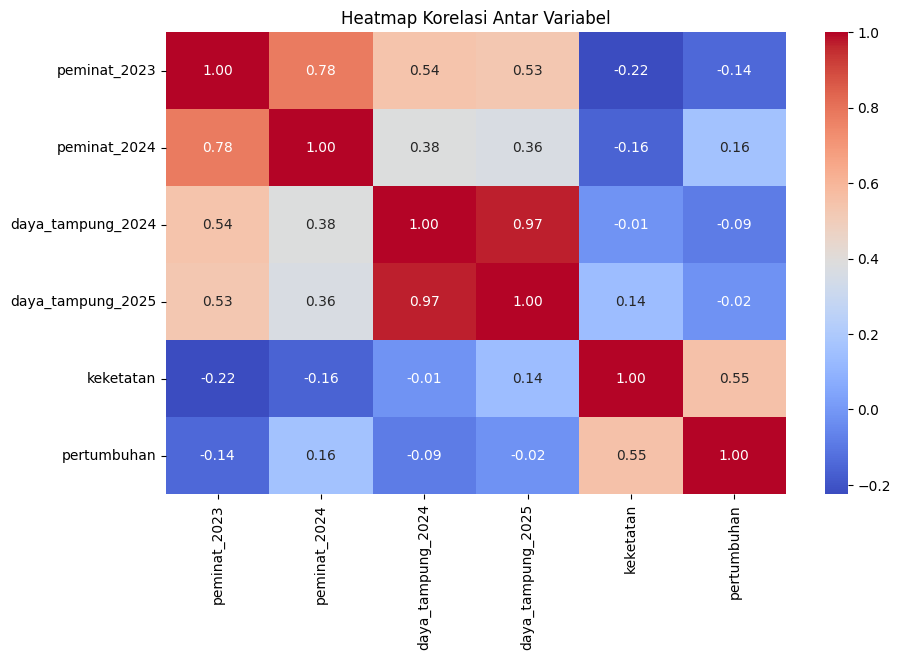


INTERPRETASI KEKUATAN KORELASI
peminat_2023 vs peminat_2024 = 0.776 (Kuat)
peminat_2023 vs daya_tampung_2024 = 0.543 (Sedang)
peminat_2023 vs daya_tampung_2025 = 0.529 (Sedang)
peminat_2023 vs keketatan = -0.224 (Lemah)
peminat_2023 vs pertumbuhan = -0.144 (Sangat Lemah)
peminat_2024 vs peminat_2023 = 0.776 (Kuat)
peminat_2024 vs daya_tampung_2024 = 0.384 (Lemah)
peminat_2024 vs daya_tampung_2025 = 0.365 (Lemah)
peminat_2024 vs keketatan = -0.160 (Sangat Lemah)
peminat_2024 vs pertumbuhan = 0.159 (Sangat Lemah)
daya_tampung_2024 vs peminat_2023 = 0.543 (Sedang)
daya_tampung_2024 vs peminat_2024 = 0.384 (Lemah)
daya_tampung_2024 vs daya_tampung_2025 = 0.970 (Sangat Kuat)
daya_tampung_2024 vs keketatan = -0.014 (Sangat Lemah)
daya_tampung_2024 vs pertumbuhan = -0.087 (Sangat Lemah)
daya_tampung_2025 vs peminat_2023 = 0.529 (Sedang)
daya_tampung_2025 vs peminat_2024 = 0.365 (Lemah)
daya_tampung_2025 vs daya_tampung_2024 = 0.970 (Sangat Kuat)
daya_tampung_2025 vs keketatan = 0.138 (Sangat

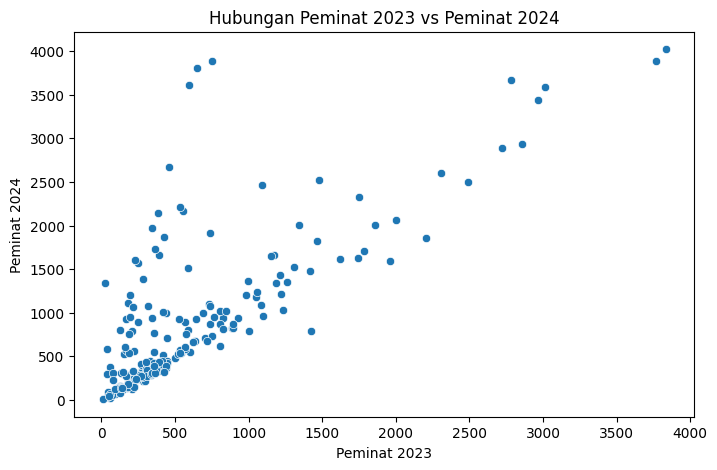

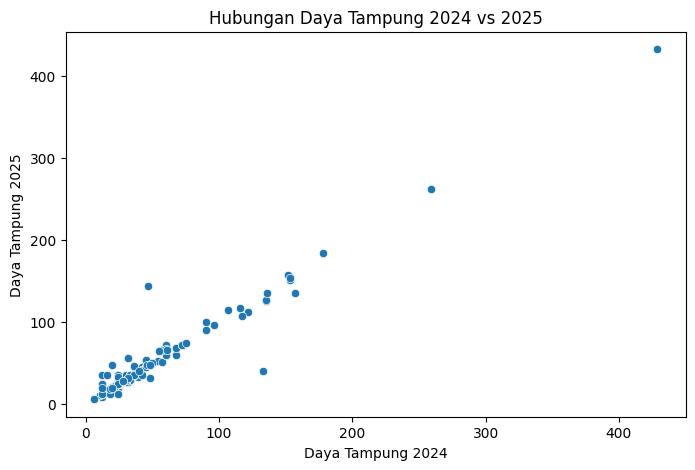

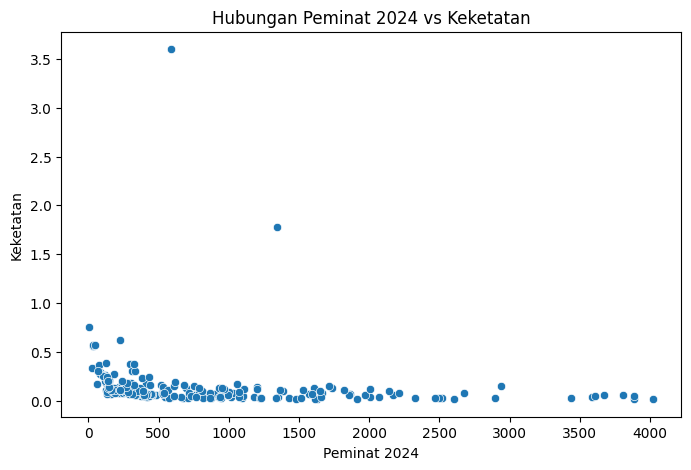

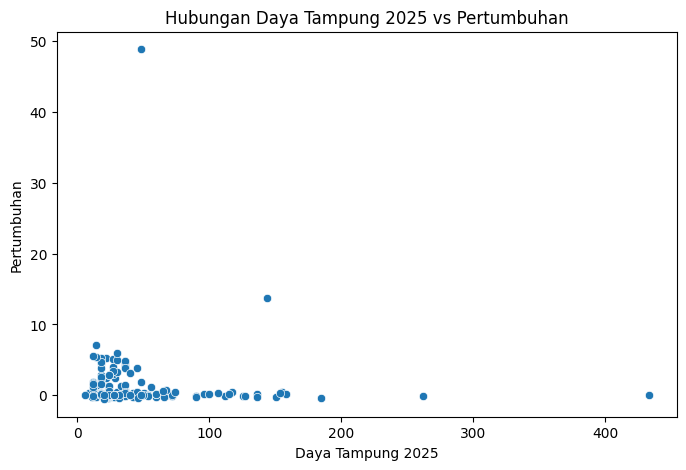


DETEKSI MULTICOLLINEARITY

daya_tampung_2024 dan daya_tampung_2025
memiliki korelasi sangat tinggi = 0.970
indikasi multicollinearity


daya_tampung_2025 dan daya_tampung_2024
memiliki korelasi sangat tinggi = 0.970
indikasi multicollinearity



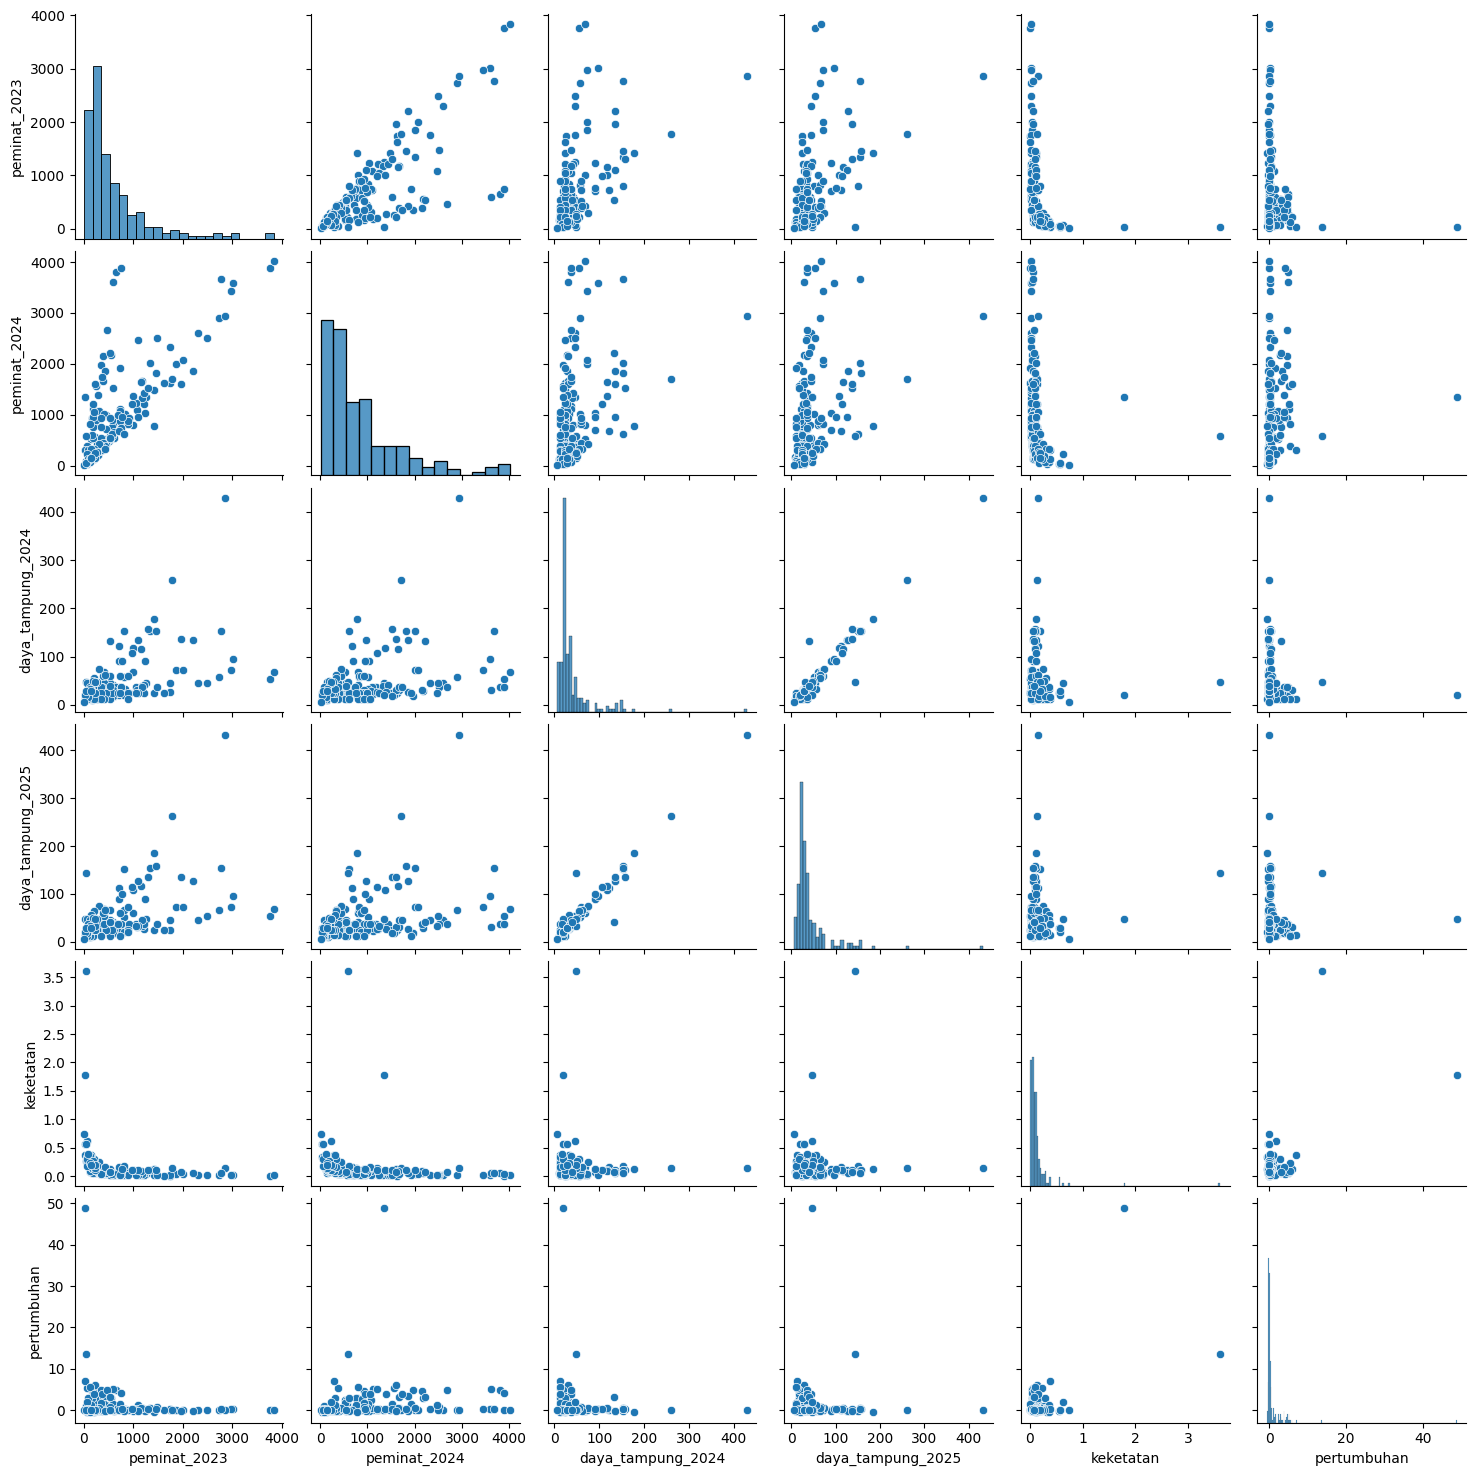


KORELASI TERHADAP KEKETATAN
keketatan            1.000000
pertumbuhan          0.552008
daya_tampung_2025    0.137796
daya_tampung_2024   -0.014286
peminat_2024        -0.160154
peminat_2023        -0.223952
Name: keketatan, dtype: float64

KORELASI TERHADAP PERTUMBUHAN
pertumbuhan          1.000000
keketatan            0.552008
peminat_2024         0.159119
daya_tampung_2025   -0.018923
daya_tampung_2024   -0.087389
peminat_2023        -0.144029
Name: pertumbuhan, dtype: float64

TOP 10 PERTUMBUHAN TERTINGGI
                                                 prodi univ  pertumbuhan  \
194                                     Etnomusikologi  ISI    48.814815   
188                                       Teknik Kimia  UPN    13.675000   
151                   Pengobatan Tradisional Indonesia  UNY     7.081081   
88                     Pembangunan Ekonomi Kewilayahan  UGM     6.017467   
152                                  Promosi Kesehatan  UNY     5.560976   
150                         

In [12]:
# ==========================================
# 3. ANALISIS KORELASI
# ==========================================

# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# ==========================================
# MEMBERSIHKAN NAMA KOLOM
# ==========================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# ==========================================
# HAPUS DUPLIKAT
# ==========================================
df = df.drop_duplicates()

# ==========================================
# HANDLE MISSING VALUE
# ==========================================
df = df.fillna(df.median(numeric_only=True))

# ==========================================
# PILIH KOLOM NUMERIK
# ==========================================
kolom_numerik = [
    'peminat_2023',
    'peminat_2024',
    'daya_tampung_2024',
    'daya_tampung_2025',
    'keketatan',
    'pertumbuhan'
]

# ==========================================
# CEK KORELASI
# ==========================================
corr = df[kolom_numerik].corr()

print("===================================")
print("MATRIX KORELASI")
print("===================================")
print(corr)

# ==========================================
# HEATMAP KORELASI
# ==========================================
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Heatmap Korelasi Antar Variabel")

plt.show()

# ==========================================
# KATEGORI KEKUATAN KORELASI
# ==========================================
print("\n===================================")
print("INTERPRETASI KEKUATAN KORELASI")
print("===================================")

for i in corr.columns:
    for j in corr.columns:

        if i != j:

            nilai = corr.loc[i, j]

            if abs(nilai) >= 0.80:
                kategori = "Sangat Kuat"

            elif abs(nilai) >= 0.60:
                kategori = "Kuat"

            elif abs(nilai) >= 0.40:
                kategori = "Sedang"

            elif abs(nilai) >= 0.20:
                kategori = "Lemah"

            else:
                kategori = "Sangat Lemah"

            print(f"{i} vs {j} = {nilai:.3f} ({kategori})")

# ==========================================
# SCATTER PEMINAT 2023 vs PEMINAT 2024
# ==========================================
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='peminat_2023',
    y='peminat_2024'
)

plt.title("Hubungan Peminat 2023 vs Peminat 2024")
plt.xlabel("Peminat 2023")
plt.ylabel("Peminat 2024")

plt.show()

# ==========================================
# SCATTER DAYA TAMPUNG 2024 vs 2025
# ==========================================
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='daya_tampung_2024',
    y='daya_tampung_2025'
)

plt.title("Hubungan Daya Tampung 2024 vs 2025")
plt.xlabel("Daya Tampung 2024")
plt.ylabel("Daya Tampung 2025")

plt.show()

# ==========================================
# SCATTER PEMINAT 2024 vs KEKETATAN
# ==========================================
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='peminat_2024',
    y='keketatan'
)

plt.title("Hubungan Peminat 2024 vs Keketatan")
plt.xlabel("Peminat 2024")
plt.ylabel("Keketatan")

plt.show()

# ==========================================
# SCATTER DAYA TAMPUNG vs PERTUMBUHAN
# ==========================================
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='daya_tampung_2025',
    y='pertumbuhan'
)

plt.title("Hubungan Daya Tampung 2025 vs Pertumbuhan")
plt.xlabel("Daya Tampung 2025")
plt.ylabel("Pertumbuhan")

plt.show()

# ==========================================
# DETEKSI MULTICOLLINEARITY
# ==========================================
print("\n===================================")
print("DETEKSI MULTICOLLINEARITY")
print("===================================")

for i in corr.columns:
    for j in corr.columns:

        if i != j:

            nilai = corr.loc[i, j]

            if abs(nilai) > 0.90:

                print(f"""
WARNING:
{i} dan {j}
memiliki korelasi sangat tinggi = {nilai:.3f}
indikasi multicollinearity
""")

# ==========================================
# PAIRPLOT SEMUA VARIABEL
# ==========================================
sns.pairplot(
    df[kolom_numerik]
)

plt.show()

# ==========================================
# KORELASI TERHADAP KEKETATAN
# ==========================================
print("\n===================================")
print("KORELASI TERHADAP KEKETATAN")
print("===================================")

target_corr = corr['keketatan'].sort_values(
    ascending=False
)

print(target_corr)

# ==========================================
# KORELASI TERHADAP PERTUMBUHAN
# ==========================================
print("\n===================================")
print("KORELASI TERHADAP PERTUMBUHAN")
print("===================================")

growth_corr = corr['pertumbuhan'].sort_values(
    ascending=False
)

print(growth_corr)

# ==========================================
# TOP 10 PRODI DENGAN PERTUMBUHAN TERTINGGI
# ==========================================
print("\n===================================")
print("TOP 10 PERTUMBUHAN TERTINGGI")
print("===================================")

top_growth = df.sort_values(
    by='pertumbuhan',
    ascending=False
)

print(
    top_growth[
        [
            'prodi',
            'univ',
            'pertumbuhan',
            'peminat_2023',
            'peminat_2024'
        ]
    ].head(10)
)

# ==========================================
# TOP 10 PRODI PALING KETAT
# ==========================================
print("\n===================================")
print("TOP 10 PRODI PALING KETAT")
print("===================================")

top_ketat = df.sort_values(
    by='keketatan',
    ascending=True
)

print(
    top_ketat[
        [
            'prodi',
            'univ',
            'keketatan',
            'peminat_2024',
            'daya_tampung_2025'
        ]
    ].head(10)
)

# ==========================================
# TOP 10 PRODI PALING LONGGAR
# ==========================================
print("\n===================================")
print("TOP 10 PRODI PALING LONGGAR")
print("===================================")

longgar = df.sort_values(
    by='keketatan',
    ascending=False
)

print(
    longgar[
        [
            'prodi',
            'univ',
            'keketatan',
            'peminat_2024',
            'daya_tampung_2025'
        ]
    ].head(10)
)

UKURAN DATA SETELAH CLEANING
(208, 8)

DATA SEBELUM NORMALISASI
   peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
0         420.0         516.0               68.0               68.0   
1        1859.0        2004.0               72.0               72.0   
2         439.0         362.0               33.0               30.0   
3         278.0         346.0               30.0               30.0   
4         336.0         289.0               24.0               24.0   

   keketatan  pertumbuhan  
0   0.161905     0.228571  
1   0.038731     0.077999  
2   0.068337    -0.175399  
3   0.107914     0.244604  
4   0.071429    -0.139881  

STATISTIK DATA AWAL
       peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
count    208.000000    208.000000         208.000000          208.00000   
mean     603.350962    866.418269          40.995192           42.31250   
std      672.199387    866.261691          44.510380           44.41475   
min        8.000000 

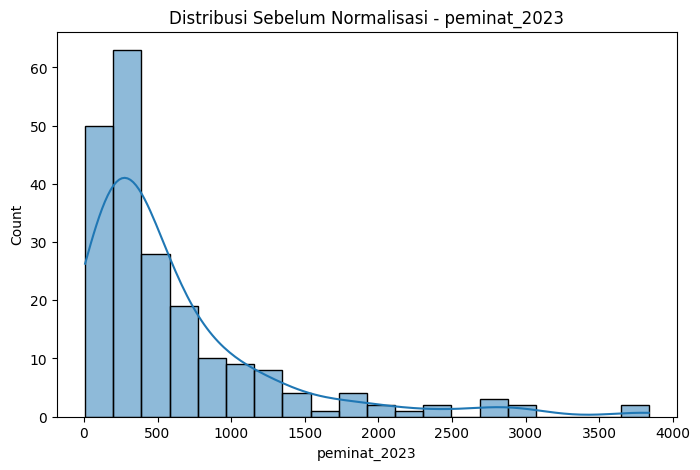

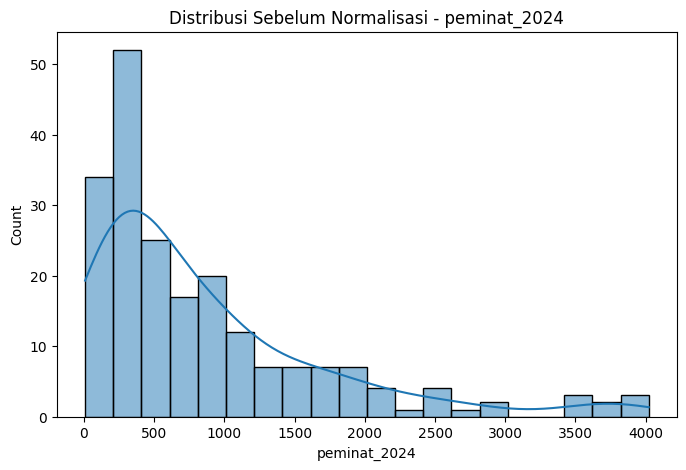

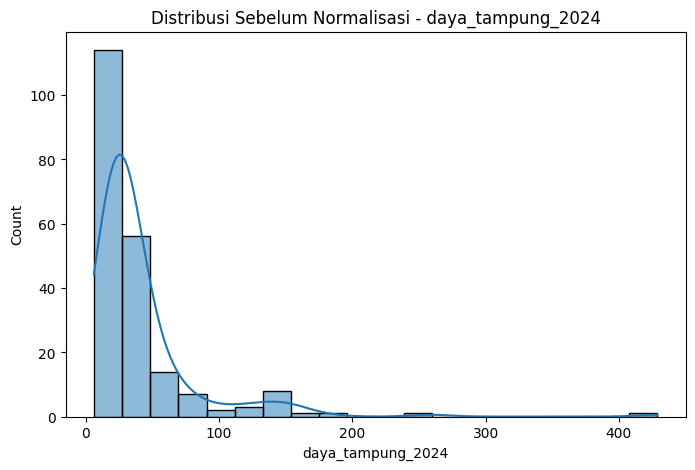

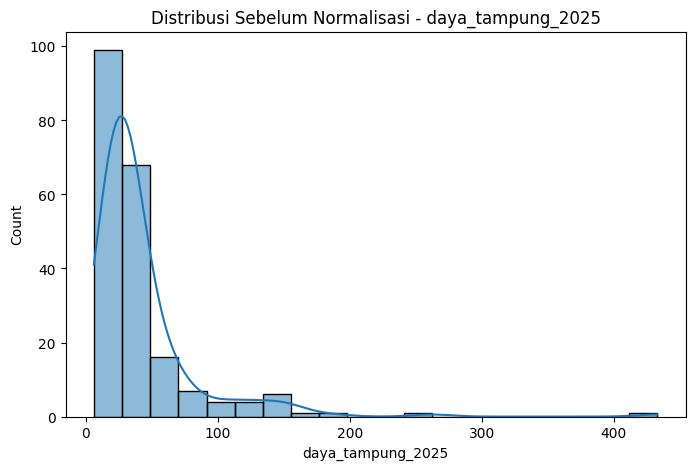

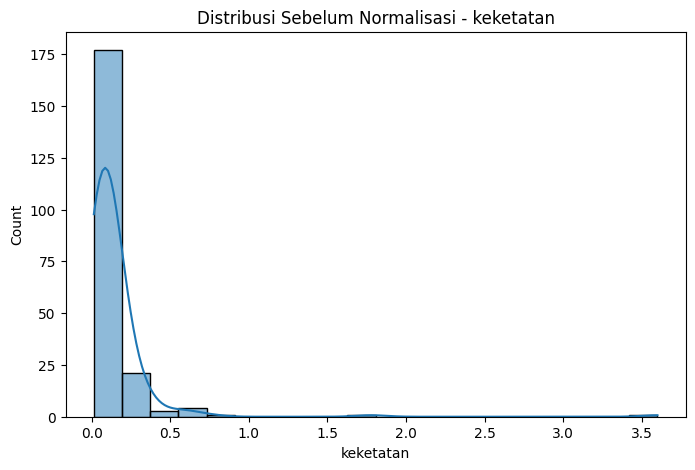

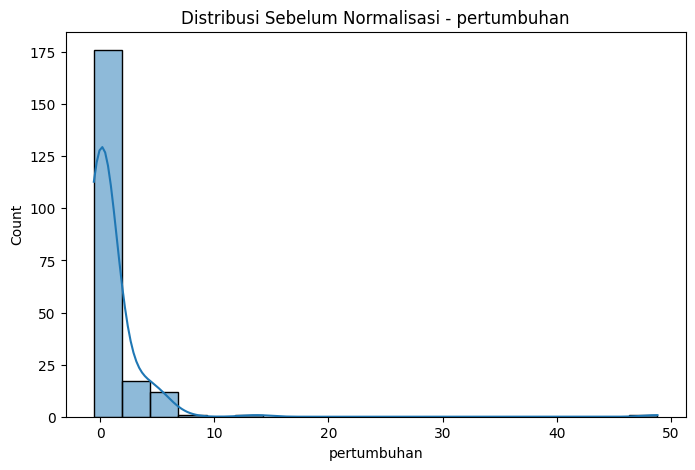


HASIL STANDARD SCALER
   peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
0     -0.273421     -0.405494           0.608172           0.579750   
1      1.872478      1.316376           0.698255           0.670028   
2     -0.245087     -0.583698          -0.180059          -0.277885   
3     -0.485177     -0.602213          -0.247621          -0.277885   
4     -0.398685     -0.668171          -0.382747          -0.413301   

   keketatan  pertumbuhan  
0   0.069560    -0.215102  
1  -0.357989    -0.255265  
2  -0.255222    -0.322856  
3  -0.117848    -0.210825  
4  -0.244491    -0.313382  

STATISTIK STANDARD SCALER
       peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
count        208.00        208.00             208.00             208.00   
mean          -0.00         -0.00               0.00               0.00   
std            1.00          1.00               1.00               1.00   
min           -0.89         -0.99              -0.79   

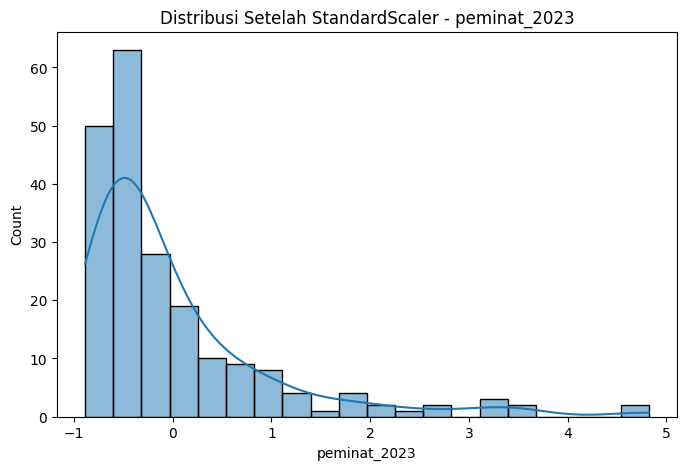

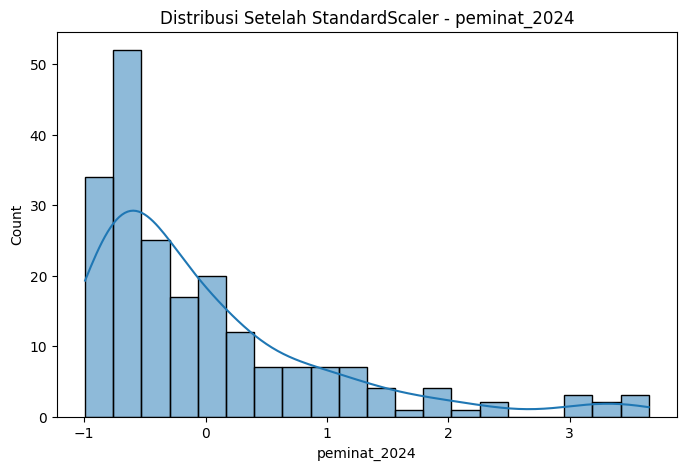

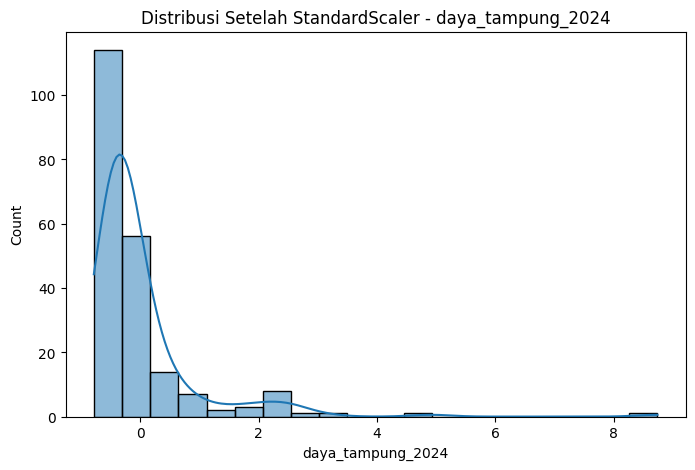

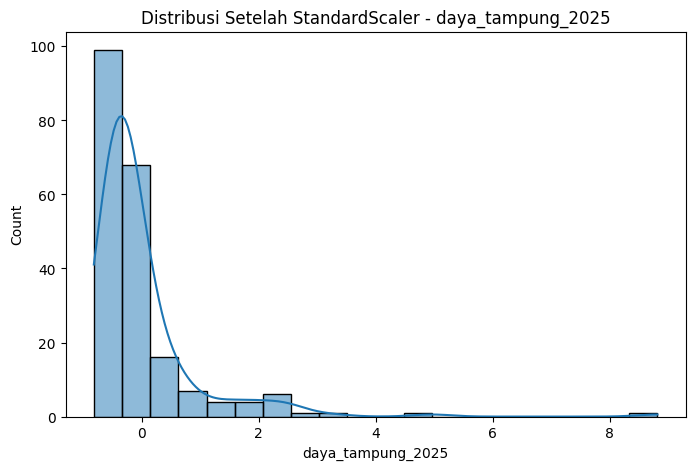

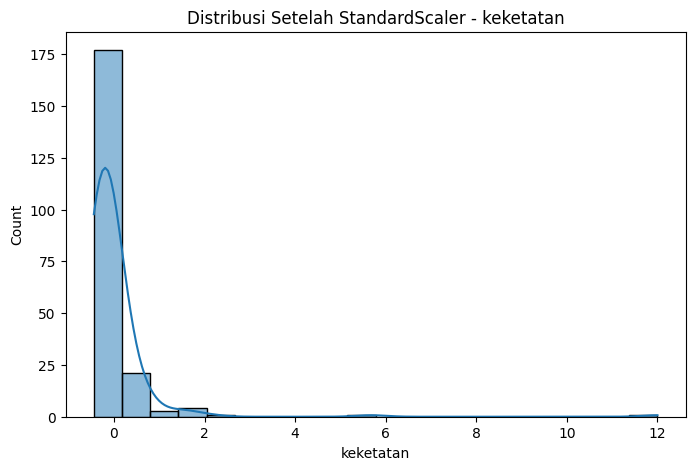

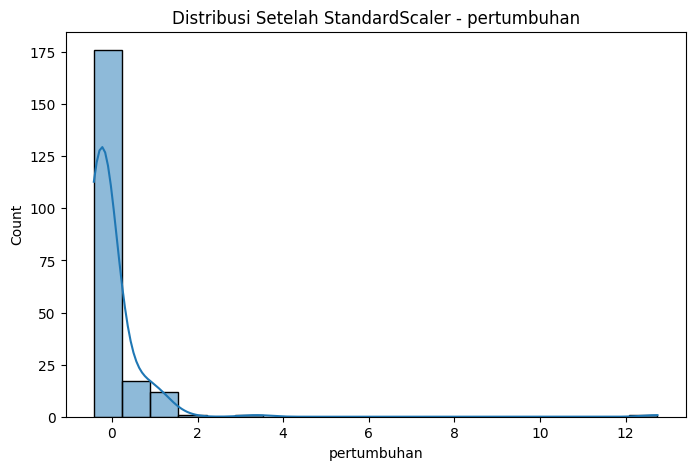


HASIL MINMAX SCALER
   peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
0      0.107600      0.126557           0.146572           0.145199   
1      0.483416      0.497260           0.156028           0.154567   
2      0.112562      0.088191           0.063830           0.056206   
3      0.070514      0.084205           0.056738           0.056206   
4      0.085662      0.070005           0.042553           0.042155   

   keketatan  pertumbuhan  
0   0.041300     0.015772  
1   0.006954     0.012722  
2   0.015209     0.007588  
3   0.026245     0.016097  
4   0.016071     0.008308  

STATISTIK MINMAX SCALER
       peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
count        208.00        208.00             208.00             208.00   
mean           0.16          0.21               0.08               0.09   
std            0.18          0.22               0.11               0.10   
min            0.00          0.00               0.00       

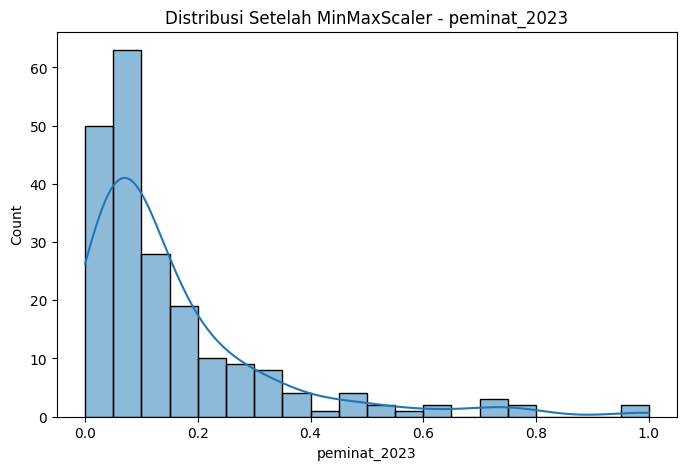

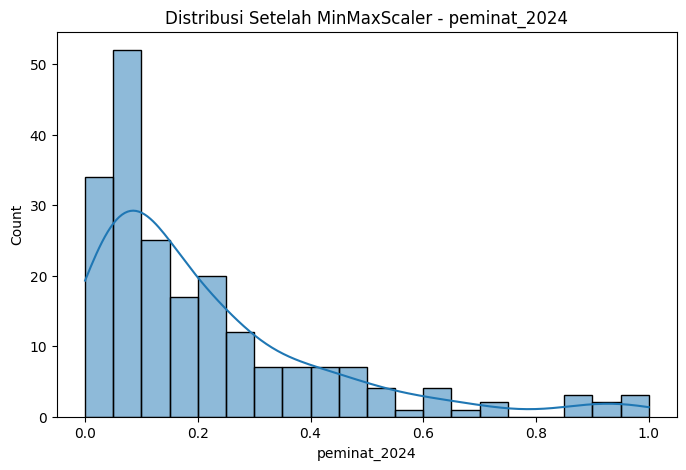

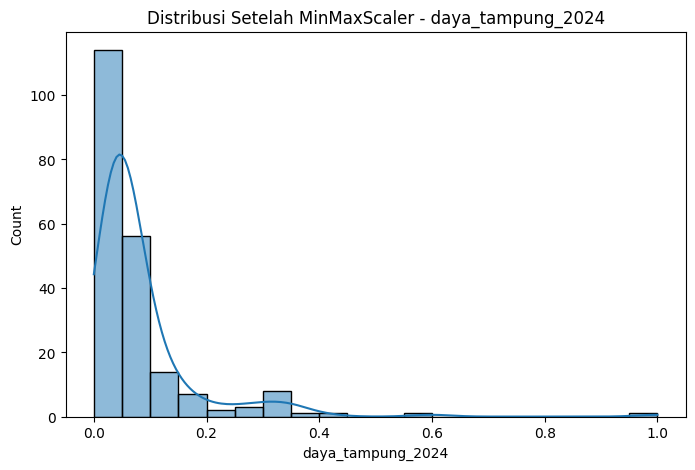

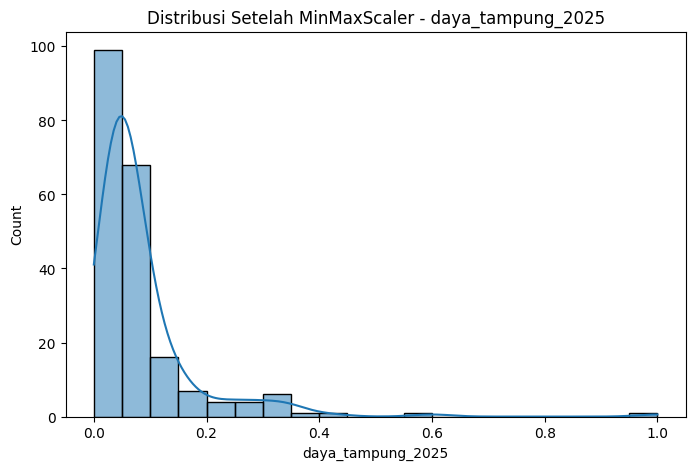

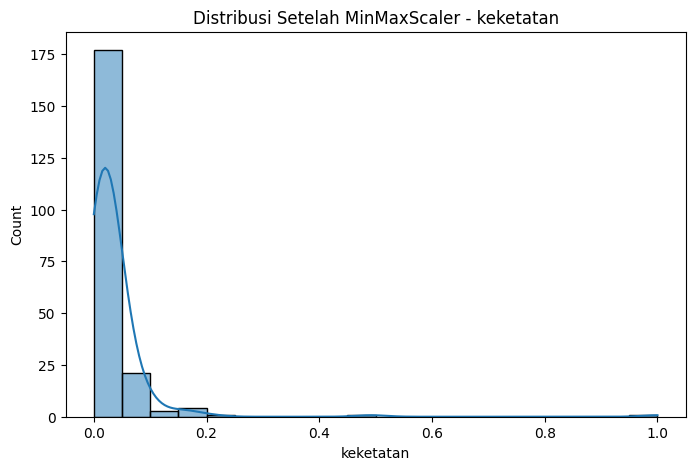

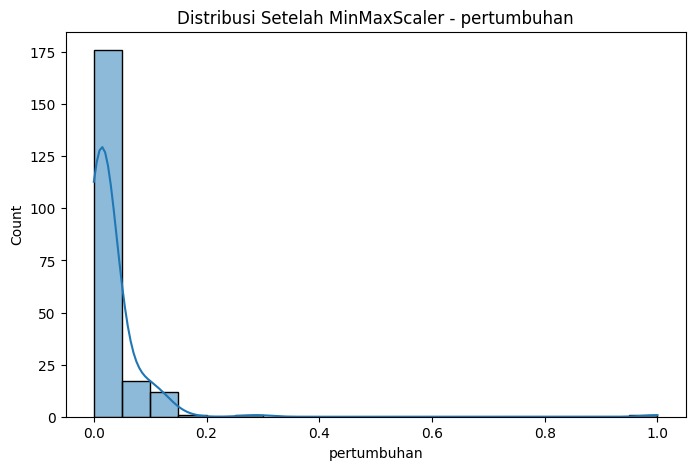


PERBANDINGAN RANGE

peminat_2023

SEBELUM:
MIN = 8.0
MAX = 3837.0

SETELAH STANDARD:
MIN = -0.89
MAX = 4.82

SETELAH MINMAX:
MIN = 0.00
MAX = 1.00


peminat_2024

SEBELUM:
MIN = 8.0
MAX = 4022.0

SETELAH STANDARD:
MIN = -0.99
MAX = 3.65

SETELAH MINMAX:
MIN = 0.00
MAX = 1.00


daya_tampung_2024

SEBELUM:
MIN = 6.0
MAX = 429.0

SETELAH STANDARD:
MIN = -0.79
MAX = 8.74

SETELAH MINMAX:
MIN = 0.00
MAX = 1.00


daya_tampung_2025

SEBELUM:
MIN = 6.0
MAX = 433.0

SETELAH STANDARD:
MIN = -0.82
MAX = 8.82

SETELAH MINMAX:
MIN = 0.00
MAX = 1.00


keketatan

SEBELUM:
MIN = 0.013793103448275862
MAX = 3.6

SETELAH STANDARD:
MIN = -0.44
MAX = 12.00

SETELAH MINMAX:
MIN = 0.00
MAX = 1.00


pertumbuhan

SEBELUM:
MIN = -0.55
MAX = 48.81481481481482

SETELAH STANDARD:
MIN = -0.42
MAX = 12.74

SETELAH MINMAX:
MIN = 0.00
MAX = 1.00


OUTLIER SETELAH STANDARD SCALER

peminat_2023
Jumlah Outlier = 7


peminat_2024
Jumlah Outlier = 7


daya_tampung_2024
Jumlah Outlier = 3


daya_tampung_2025
Jumlah Outlier

In [13]:
# ==========================================
# 4. PREPROCESSING & NORMALISASI
# ==========================================

# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# ==========================================
# MEMBERSIHKAN NAMA KOLOM
# ==========================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# ==========================================
# HAPUS DUPLIKAT
# ==========================================
df = df.drop_duplicates()

# ==========================================
# HANDLE MISSING VALUE
# ==========================================
df = df.fillna(df.median(numeric_only=True))

# ==========================================
# CEK DATA SETELAH CLEANING
# ==========================================
print("===================================")
print("UKURAN DATA SETELAH CLEANING")
print("===================================")
print(df.shape)

# ==========================================
# PILIH FITUR UNTUK CLUSTERING
# ==========================================
fitur = [
    'peminat_2023',
    'peminat_2024',
    'daya_tampung_2024',
    'daya_tampung_2025',
    'keketatan',
    'pertumbuhan'
]

X = df[fitur]

# ==========================================
# TAMPILKAN DATA AWAL
# ==========================================
print("\n===================================")
print("DATA SEBELUM NORMALISASI")
print("===================================")

print(X.head())

# ==========================================
# STATISTIK DATA AWAL
# ==========================================
print("\n===================================")
print("STATISTIK DATA AWAL")
print("===================================")

print(X.describe())

# ==========================================
# CEK RANGE DATA
# ==========================================
print("\n===================================")
print("RANGE DATA")
print("===================================")

for kolom in fitur:

    print(f"""
{kolom}
MIN : {X[kolom].min()}
MAX : {X[kolom].max()}
""")

# ==========================================
# VISUALISASI DISTRIBUSI SEBELUM NORMALISASI
# ==========================================
for kolom in fitur:

    plt.figure(figsize=(8,5))

    sns.histplot(
        X[kolom],
        bins=20,
        kde=True
    )

    plt.title(f"Distribusi Sebelum Normalisasi - {kolom}")

    plt.show()

# ==========================================
# STANDARD SCALER
# ==========================================
standard_scaler = StandardScaler()

X_standard = standard_scaler.fit_transform(X)

X_standard = pd.DataFrame(
    X_standard,
    columns=fitur
)

# ==========================================
# HASIL STANDARD SCALER
# ==========================================
print("\n===================================")
print("HASIL STANDARD SCALER")
print("===================================")

print(X_standard.head())

# ==========================================
# STATISTIK SETELAH STANDARD SCALER
# ==========================================
print("\n===================================")
print("STATISTIK STANDARD SCALER")
print("===================================")

print(
    X_standard.describe().round(2)
)

# ==========================================
# CEK MEAN & STD
# ==========================================
print("\n===================================")
print("MEAN & STD SETELAH STANDARD SCALER")
print("===================================")

for kolom in fitur:

    print(f"""
{kolom}
MEAN : {X_standard[kolom].mean():.2f}
STD  : {X_standard[kolom].std():.2f}
""")

# ==========================================
# VISUALISASI SETELAH STANDARD SCALER
# ==========================================
for kolom in fitur:

    plt.figure(figsize=(8,5))

    sns.histplot(
        X_standard[kolom],
        bins=20,
        kde=True
    )

    plt.title(f"Distribusi Setelah StandardScaler - {kolom}")

    plt.show()

# ==========================================
# MIN MAX SCALER
# ==========================================
minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X)

X_minmax = pd.DataFrame(
    X_minmax,
    columns=fitur
)

# ==========================================
# HASIL MINMAX SCALER
# ==========================================
print("\n===================================")
print("HASIL MINMAX SCALER")
print("===================================")

print(X_minmax.head())

# ==========================================
# STATISTIK MINMAX
# ==========================================
print("\n===================================")
print("STATISTIK MINMAX SCALER")
print("===================================")

print(
    X_minmax.describe().round(2)
)

# ==========================================
# VISUALISASI MINMAX SCALER
# ==========================================
for kolom in fitur:

    plt.figure(figsize=(8,5))

    sns.histplot(
        X_minmax[kolom],
        bins=20,
        kde=True
    )

    plt.title(f"Distribusi Setelah MinMaxScaler - {kolom}")

    plt.show()

# ==========================================
# PERBANDINGAN SEBELUM & SESUDAH
# ==========================================
print("\n===================================")
print("PERBANDINGAN RANGE")
print("===================================")

for kolom in fitur:

    print(f"""
{kolom}

SEBELUM:
MIN = {X[kolom].min()}
MAX = {X[kolom].max()}

SETELAH STANDARD:
MIN = {X_standard[kolom].min():.2f}
MAX = {X_standard[kolom].max():.2f}

SETELAH MINMAX:
MIN = {X_minmax[kolom].min():.2f}
MAX = {X_minmax[kolom].max():.2f}
""")

# ==========================================
# DETEKSI OUTLIER SETELAH STANDARD SCALER
# ==========================================
print("\n===================================")
print("OUTLIER SETELAH STANDARD SCALER")
print("===================================")

z_threshold = 3

for kolom in fitur:

    outlier = X_standard[
        np.abs(X_standard[kolom]) > z_threshold
    ]

    print(f"""
{kolom}
Jumlah Outlier = {outlier.shape[0]}
""")

# ==========================================
# SIMPAN DATA NORMALISASI
# ==========================================
X_standard.to_csv(
    "data_standard_scaler.csv",
    index=False
)

X_minmax.to_csv(
    "data_minmax_scaler.csv",
    index=False
)

print("\n===================================")
print("FILE NORMALISASI BERHASIL DISIMPAN")
print("===================================")

# ==========================================
# KESIMPULAN NORMALISASI
# ==========================================
print("""
===================================
KESIMPULAN
===================================

1. StandardScaler:
   - Mean mendekati 0
   - Std mendekati 1
   - Cocok untuk KMeans

2. MinMaxScaler:
   - Range 0 sampai 1
   - Sensitif terhadap outlier

3. Dataset memiliki:
   - distribusi skewed
   - outlier ekstrem
   - perbedaan skala besar

4. StandardScaler lebih cocok
   untuk clustering dataset ini
""")

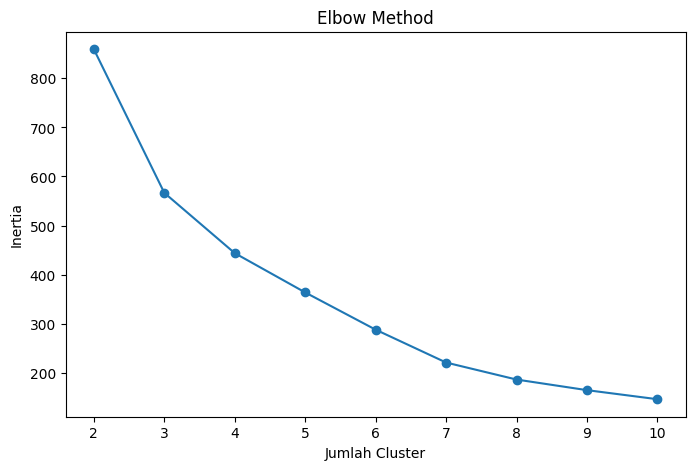

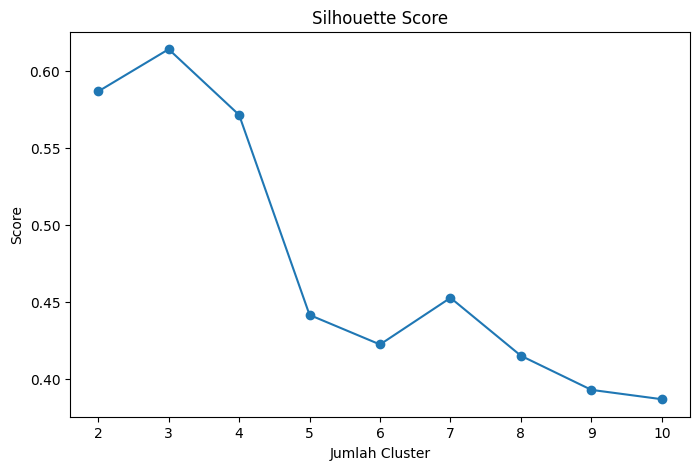

CLUSTER TERBAIK
Jumlah Cluster Terbaik : 3
Silhouette Score       : 0.6139

TABEL EVALUASI
   cluster     inertia  silhouette_score
0        2  859.309554          0.586477
1        3  566.725444          0.613887
2        4  443.797715          0.571214
3        5  363.738529          0.441311
4        6  287.852274          0.422129
5        7  220.893533          0.452446
6        8  186.241476          0.414810
7        9  164.631706          0.392662
8       10  146.159456          0.386587


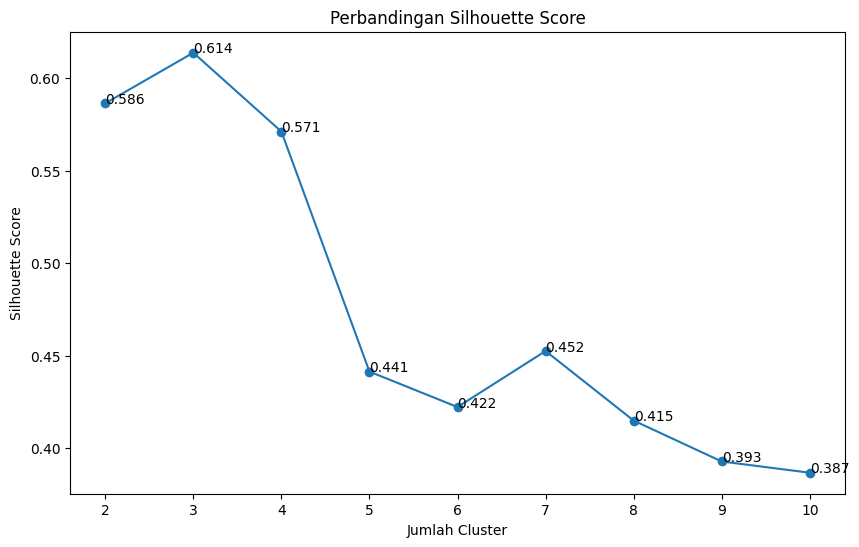


PENURUNAN INERTIA

Cluster 2 -> 3
Penurunan Inertia : 292.58


Cluster 3 -> 4
Penurunan Inertia : 122.93


Cluster 4 -> 5
Penurunan Inertia : 80.06


Cluster 5 -> 6
Penurunan Inertia : 75.89


Cluster 6 -> 7
Penurunan Inertia : 66.96


Cluster 7 -> 8
Penurunan Inertia : 34.65


Cluster 8 -> 9
Penurunan Inertia : 21.61


Cluster 9 -> 10
Penurunan Inertia : 18.47


INTERPRETASI SILHOUETTE

Cluster 2
Score    : 0.5865
Kategori : Baik


Cluster 3
Score    : 0.6139
Kategori : Baik


Cluster 4
Score    : 0.5712
Kategori : Baik


Cluster 5
Score    : 0.4413
Kategori : Cukup


Cluster 6
Score    : 0.4221
Kategori : Cukup


Cluster 7
Score    : 0.4524
Kategori : Cukup


Cluster 8
Score    : 0.4148
Kategori : Cukup


Cluster 9
Score    : 0.3927
Kategori : Cukup


Cluster 10
Score    : 0.3866
Kategori : Cukup


JUMLAH DATA PER CLUSTER
cluster
0    176
1     30
2      2
Name: count, dtype: int64

CENTROID CLUSTER
   peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
0    404.4829

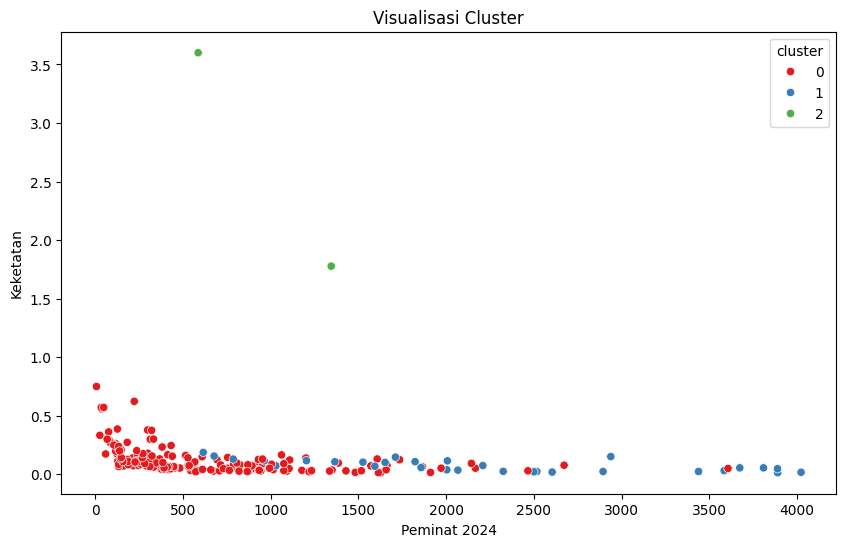


RATA-RATA TIAP CLUSTER
         peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
cluster                                                                     
0          404.482955    631.295455          28.414773          29.852273   
1         1808.033333   2239.166667         115.300000         111.833333   
2           33.500000    966.000000          33.500000          96.000000   

         keketatan  pertumbuhan  
cluster                          
0         0.124310     0.783773  
1         0.075054     0.494808  
2         2.688889    31.244907  

ANGGOTA CLUSTER

========== CLUSTER 0 ==========
                                  prodi univ  peminat_2024  keketatan
0                               Biologi  UGM         516.0   0.161905
2                   Geografi Lingkungan  UGM         362.0   0.068337
3      Kartografi Dan Penginderaan Jauh  UGM         346.0   0.107914
4                   Pembangunan Wilayah  UGM         289.0   0.071429
6                   

In [14]:
# ==========================================
# 5. MENENTUKAN CLUSTER OPTIMAL
# ==========================================

# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# ==========================================
# MEMBERSIHKAN NAMA KOLOM
# ==========================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# ==========================================
# HAPUS DUPLIKAT
# ==========================================
df = df.drop_duplicates()

# ==========================================
# HANDLE MISSING VALUE
# ==========================================
df = df.fillna(df.median(numeric_only=True))

# ==========================================
# PILIH FITUR
# ==========================================
fitur = [
    'peminat_2023',
    'peminat_2024',
    'daya_tampung_2024',
    'daya_tampung_2025',
    'keketatan',
    'pertumbuhan'
]

X = df[fitur]

# ==========================================
# NORMALISASI DATA
# ==========================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# ELBOW METHOD
# ==========================================
inertia = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# ==========================================
# VISUALISASI ELBOW
# ==========================================
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")

plt.show()

# ==========================================
# SILHOUETTE SCORE
# ==========================================
silhouette_scores = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

# ==========================================
# VISUALISASI SILHOUETTE SCORE
# ==========================================
plt.figure(figsize=(8,5))

plt.plot(
    K,
    silhouette_scores,
    marker='o'
)

plt.title("Silhouette Score")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Score")

plt.show()

# ==========================================
# CLUSTER TERBAIK
# ==========================================
best_k = K[
    silhouette_scores.index(
        max(silhouette_scores)
    )
]

best_score = max(silhouette_scores)

print("===================================")
print("CLUSTER TERBAIK")
print("===================================")

print(f"Jumlah Cluster Terbaik : {best_k}")
print(f"Silhouette Score       : {best_score:.4f}")

# ==========================================
# TABEL EVALUASI
# ==========================================
evaluasi = pd.DataFrame({
    'cluster': list(K),
    'inertia': inertia,
    'silhouette_score': silhouette_scores
})

print("\n===================================")
print("TABEL EVALUASI")
print("===================================")

print(evaluasi)

# ==========================================
# VISUALISASI PERBANDINGAN
# ==========================================
plt.figure(figsize=(10,6))

plt.plot(
    evaluasi['cluster'],
    evaluasi['silhouette_score'],
    marker='o'
)

for i in range(len(evaluasi)):

    plt.text(
        evaluasi['cluster'][i],
        evaluasi['silhouette_score'][i],
        round(
            evaluasi['silhouette_score'][i],
            3
        )
    )

plt.title("Perbandingan Silhouette Score")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")

plt.show()

# ==========================================
# ANALISIS PENURUNAN INERTIA
# ==========================================
print("\n===================================")
print("PENURUNAN INERTIA")
print("===================================")

for i in range(1, len(inertia)):

    penurunan = inertia[i-1] - inertia[i]

    print(f"""
Cluster {K[i-1]} -> {K[i]}
Penurunan Inertia : {penurunan:.2f}
""")

# ==========================================
# ANALISIS KUALITAS CLUSTER
# ==========================================
print("\n===================================")
print("INTERPRETASI SILHOUETTE")
print("===================================")

for i in range(len(K)):

    nilai = silhouette_scores[i]

    if nilai >= 0.70:
        kategori = "Sangat Baik"

    elif nilai >= 0.50:
        kategori = "Baik"

    elif nilai >= 0.25:
        kategori = "Cukup"

    else:
        kategori = "Buruk"

    print(f"""
Cluster {K[i]}
Score    : {nilai:.4f}
Kategori : {kategori}
""")

# ==========================================
# CLUSTER FINAL
# ==========================================
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans_final.fit_predict(
    X_scaled
)

# ==========================================
# JUMLAH ANGGOTA CLUSTER
# ==========================================
print("\n===================================")
print("JUMLAH DATA PER CLUSTER")
print("===================================")

print(
    df['cluster']
    .value_counts()
    .sort_index()
)

# ==========================================
# CENTROID CLUSTER
# ==========================================
centroid = pd.DataFrame(
    scaler.inverse_transform(
        kmeans_final.cluster_centers_
    ),
    columns=fitur
)

print("\n===================================")
print("CENTROID CLUSTER")
print("===================================")

print(centroid)

# ==========================================
# VISUALISASI CLUSTER
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='peminat_2024',
    y='keketatan',
    hue='cluster',
    palette='Set1'
)

plt.title("Visualisasi Cluster")
plt.xlabel("Peminat 2024")
plt.ylabel("Keketatan")

plt.show()

# ==========================================
# RATA-RATA TIAP CLUSTER
# ==========================================
print("\n===================================")
print("RATA-RATA TIAP CLUSTER")
print("===================================")

cluster_summary = df.groupby('cluster')[
    fitur
].mean()

print(cluster_summary)

# ==========================================
# PRODI DALAM SETIAP CLUSTER
# ==========================================
print("\n===================================")
print("ANGGOTA CLUSTER")
print("===================================")

for c in sorted(df['cluster'].unique()):

    print(f"\n========== CLUSTER {c} ==========")

    tampil = df[
        df['cluster'] == c
    ][
        [
            'prodi',
            'univ',
            'peminat_2024',
            'keketatan'
        ]
    ]

    print(tampil.head(20))

# ==========================================
# SIMPAN HASIL CLUSTER
# ==========================================
df.to_csv(
    "hasil_clustering.csv",
    index=False
)

print("\n===================================")
print("HASIL CLUSTER BERHASIL DISIMPAN")
print("===================================")

JUMLAH ANGGOTA CLUSTER
cluster
0    176
1     30
2      2
Name: count, dtype: int64

RATA-RATA SETIAP CLUSTER
         peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
cluster                                                                     
0              404.48        631.30              28.41              29.85   
1             1808.03       2239.17             115.30             111.83   
2               33.50        966.00              33.50              96.00   

         keketatan  pertumbuhan  
cluster                          
0             0.12         0.78  
1             0.08         0.49  
2             2.69        31.24  


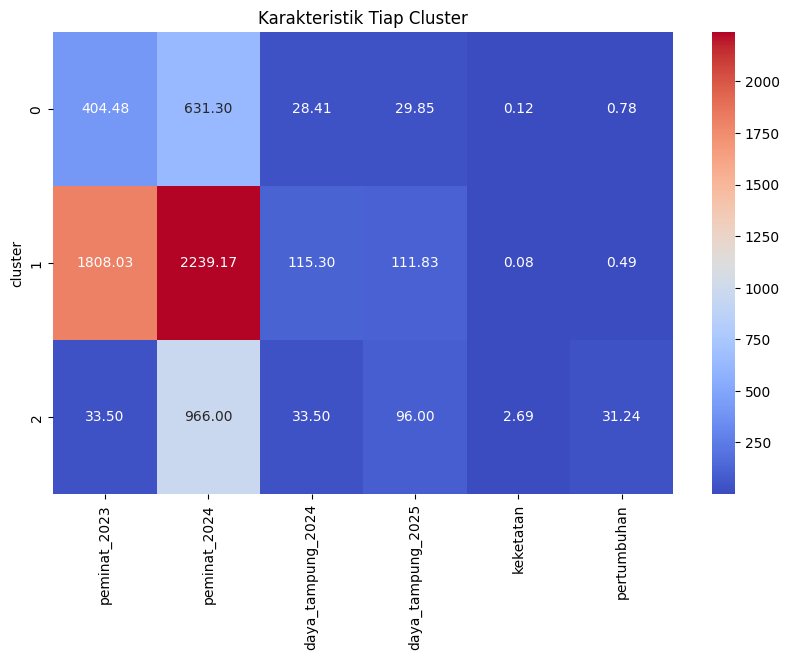

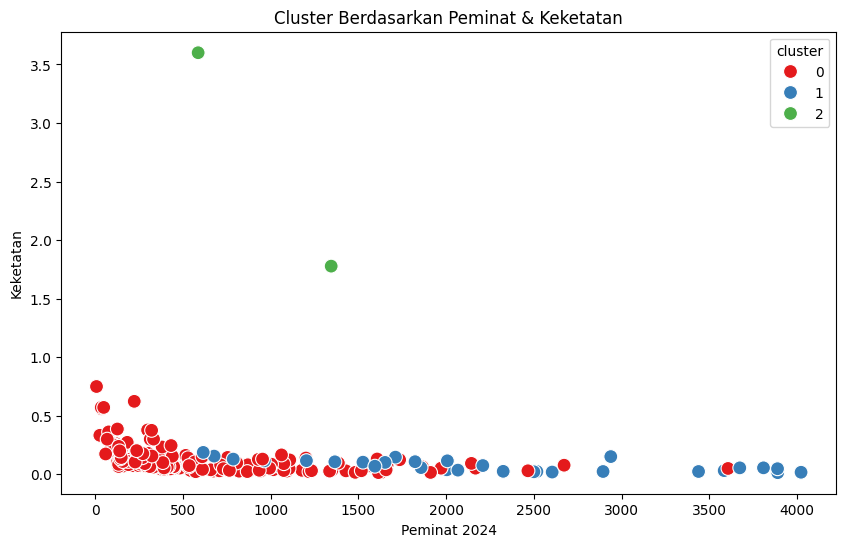

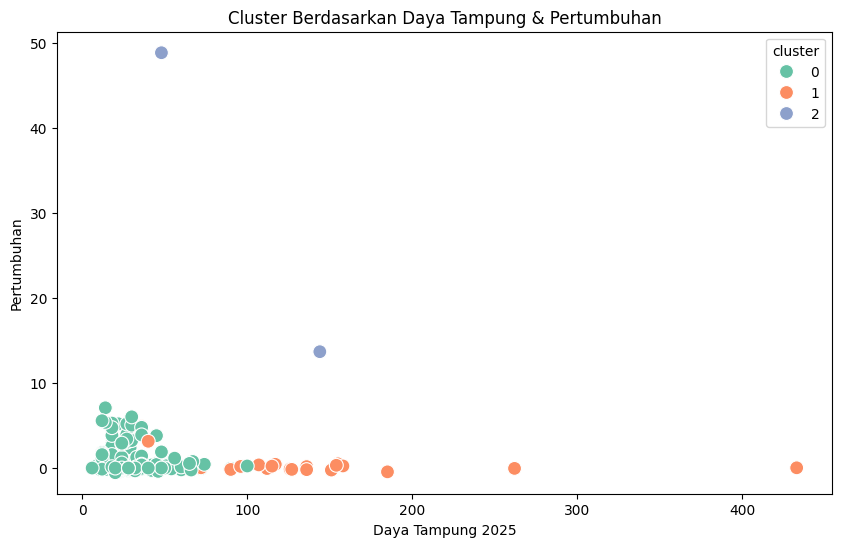


PROFIL CLUSTER

========== CLUSTER 0 ==========

Jumlah Prodi        : 176
Rata Peminat 2024  : 631.30
Rata Keketatan     : 0.1243
Rata Pertumbuhan   : 0.7838


========== CLUSTER 1 ==========

Jumlah Prodi        : 30
Rata Peminat 2024  : 2239.17
Rata Keketatan     : 0.0751
Rata Pertumbuhan   : 0.4948


========== CLUSTER 2 ==========

Jumlah Prodi        : 2
Rata Peminat 2024  : 966.00
Rata Keketatan     : 2.6889
Rata Pertumbuhan   : 31.2449


TOP PRODI TIAP CLUSTER

========== CLUSTER 0 ==========
                                  prodi univ  peminat_2024  keketatan  \
87              Akuntansi Sektor Publik  UGM        3606.0   0.050251   
107                 Manajemen Pemasaran  UNY        2672.0   0.077922   
157                           Tata Boga  UNY        2466.0   0.030247   
72   Teknologi Rekayasa Perangkat Lunak  UGM        2167.0   0.052632   
86                            Perbankan  UGM        2144.0   0.093506   
90                       Bahasa Inggris  UGM        197

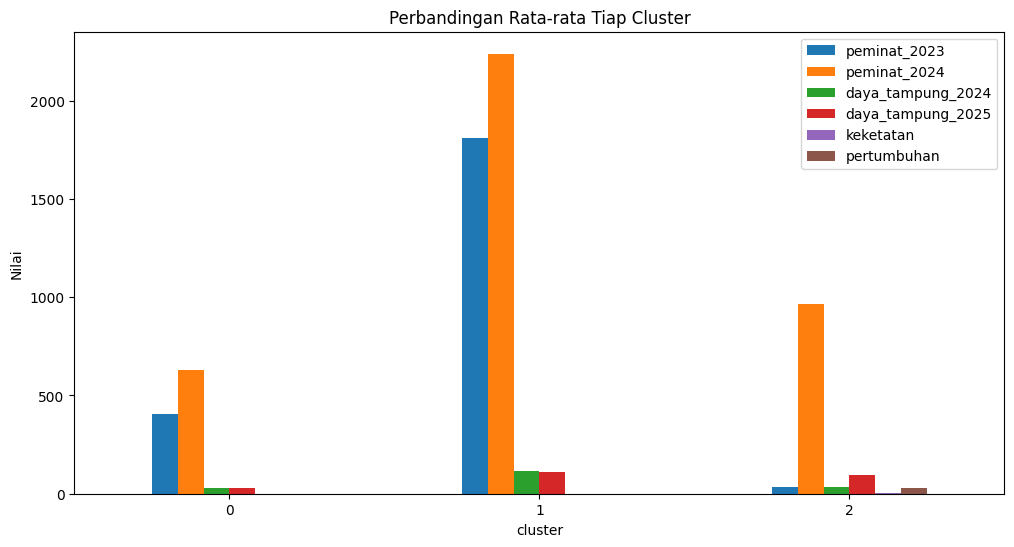


CENTROID CLUSTER
   peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
0        404.48        631.30              28.41              29.85   
1       1808.03       2239.17             115.30             111.83   
2         33.50        966.00              33.50              96.00   

   keketatan  pertumbuhan  
0       0.12         0.78  
1       0.08         0.49  
2       2.69        31.24  

HASIL ANALISIS CLUSTER DISIMPAN


In [15]:
# ==========================================
# 6. ANALISIS HASIL CLUSTERING
# ==========================================

# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# ==========================================
# MEMBERSIHKAN NAMA KOLOM
# ==========================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# ==========================================
# HAPUS DUPLIKAT
# ==========================================
df = df.drop_duplicates()

# ==========================================
# HANDLE MISSING VALUE
# ==========================================
df = df.fillna(df.median(numeric_only=True))

# ==========================================
# PILIH FITUR
# ==========================================
fitur = [
    'peminat_2023',
    'peminat_2024',
    'daya_tampung_2024',
    'daya_tampung_2025',
    'keketatan',
    'pertumbuhan'
]

X = df[fitur]

# ==========================================
# NORMALISASI DATA
# ==========================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# CLUSTERING FINAL
# ==========================================
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(
    X_scaled
)

# ==========================================
# JUMLAH ANGGOTA TIAP CLUSTER
# ==========================================
print("===================================")
print("JUMLAH ANGGOTA CLUSTER")
print("===================================")

print(
    df['cluster']
    .value_counts()
    .sort_index()
)

# ==========================================
# RATA-RATA SETIAP CLUSTER
# ==========================================
print("\n===================================")
print("RATA-RATA SETIAP CLUSTER")
print("===================================")

cluster_mean = df.groupby('cluster')[
    fitur
].mean().round(2)

print(cluster_mean)

# ==========================================
# VISUALISASI HEATMAP CLUSTER
# ==========================================
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_mean,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Karakteristik Tiap Cluster")

plt.show()

# ==========================================
# VISUALISASI SCATTER CLUSTER
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='peminat_2024',
    y='keketatan',
    hue='cluster',
    palette='Set1',
    s=100
)

plt.title("Cluster Berdasarkan Peminat & Keketatan")
plt.xlabel("Peminat 2024")
plt.ylabel("Keketatan")

plt.show()

# ==========================================
# VISUALISASI DAYA TAMPUNG
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='daya_tampung_2025',
    y='pertumbuhan',
    hue='cluster',
    palette='Set2',
    s=100
)

plt.title("Cluster Berdasarkan Daya Tampung & Pertumbuhan")
plt.xlabel("Daya Tampung 2025")
plt.ylabel("Pertumbuhan")

plt.show()

# ==========================================
# PROFIL TIAP CLUSTER
# ==========================================
print("\n===================================")
print("PROFIL CLUSTER")
print("===================================")

for c in sorted(df['cluster'].unique()):

    print(f"\n========== CLUSTER {c} ==========")

    subset = df[df['cluster'] == c]

    print(f"""
Jumlah Prodi        : {subset.shape[0]}
Rata Peminat 2024  : {subset['peminat_2024'].mean():.2f}
Rata Keketatan     : {subset['keketatan'].mean():.4f}
Rata Pertumbuhan   : {subset['pertumbuhan'].mean():.4f}
""")

# ==========================================
# TOP PRODI TIAP CLUSTER
# ==========================================
print("\n===================================")
print("TOP PRODI TIAP CLUSTER")
print("===================================")

for c in sorted(df['cluster'].unique()):

    print(f"\n========== CLUSTER {c} ==========")

    top = df[
        df['cluster'] == c
    ].sort_values(
        by='peminat_2024',
        ascending=False
    )

    print(
        top[
            [
                'prodi',
                'univ',
                'peminat_2024',
                'keketatan',
                'pertumbuhan'
            ]
        ].head(10)
    )

# ==========================================
# PRODI PALING KETAT PER CLUSTER
# ==========================================
print("\n===================================")
print("PRODI PALING KETAT PER CLUSTER")
print("===================================")

for c in sorted(df['cluster'].unique()):

    print(f"\n========== CLUSTER {c} ==========")

    ketat = df[
        df['cluster'] == c
    ].sort_values(
        by='keketatan',
        ascending=True
    )

    print(
        ketat[
            [
                'prodi',
                'univ',
                'keketatan',
                'peminat_2024'
            ]
        ].head(5)
    )

# ==========================================
# PRODI PALING LONGGAR PER CLUSTER
# ==========================================
print("\n===================================")
print("PRODI PALING LONGGAR PER CLUSTER")
print("===================================")

for c in sorted(df['cluster'].unique()):

    print(f"\n========== CLUSTER {c} ==========")

    longgar = df[
        df['cluster'] == c
    ].sort_values(
        by='keketatan',
        ascending=False
    )

    print(
        longgar[
            [
                'prodi',
                'univ',
                'keketatan',
                'peminat_2024'
            ]
        ].head(5)
    )

# ==========================================
# DETEKSI CLUSTER DOMINAN
# ==========================================
print("\n===================================")
print("INTERPRETASI CLUSTER")
print("===================================")

for c in sorted(df['cluster'].unique()):

    subset = df[df['cluster'] == c]

    rata_peminat = subset['peminat_2024'].mean()
    rata_keketatan = subset['keketatan'].mean()

    print(f"\nCluster {c}")

    if rata_peminat > 1500:
        kategori = "Prodi Sangat Populer"

    elif rata_peminat > 700:
        kategori = "Prodi Populer Menengah"

    else:
        kategori = "Prodi Kurang Diminati"

    print(f"Kategori : {kategori}")

    print(f"""
Rata Peminat 2024 : {rata_peminat:.2f}
Rata Keketatan   : {rata_keketatan:.4f}
""")

# ==========================================
# VISUALISASI BAR RATA-RATA CLUSTER
# ==========================================
cluster_mean.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Perbandingan Rata-rata Tiap Cluster")
plt.ylabel("Nilai")

plt.xticks(rotation=0)

plt.show()

# ==========================================
# CENTROID CLUSTER
# ==========================================
centroid = pd.DataFrame(
    scaler.inverse_transform(
        kmeans.cluster_centers_
    ),
    columns=fitur
)

print("\n===================================")
print("CENTROID CLUSTER")
print("===================================")

print(centroid.round(2))

# ==========================================
# SIMPAN HASIL
# ==========================================
df.to_csv(
    "hasil_analisis_cluster.csv",
    index=False
)

print("\n===================================")
print("HASIL ANALISIS CLUSTER DISIMPAN")
print("===================================")

EXPLAINED VARIANCE PCA
[0.46792374 0.26620725]

Total Variance :
0.7341309961417897


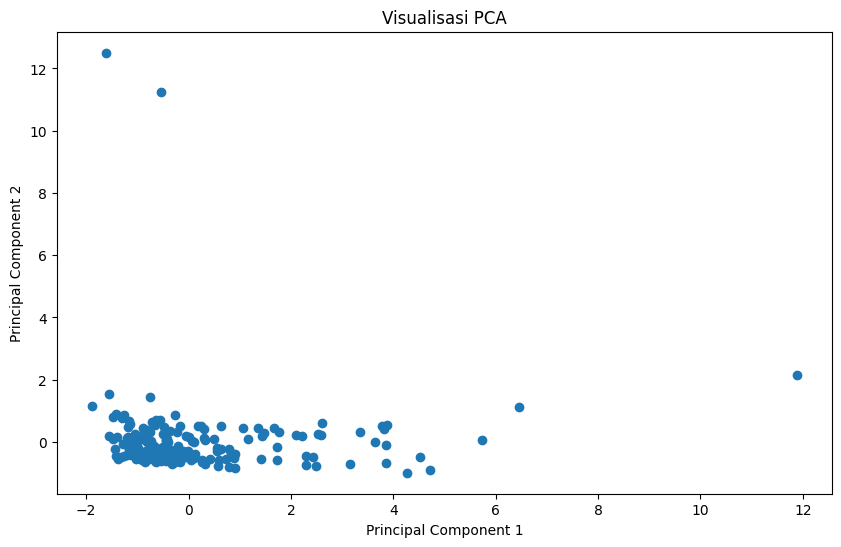


PERBANDINGAN MODEL
           Model  Silhouette Score  Davies Bouldin Index  \
0         KMeans          0.613887              0.827392   
1  Agglomerative          0.504701              0.948873   
2         DBSCAN          0.757226              1.456614   

   Calinski Harabasz Score  
0               123.217764  
1               103.650282  
2                46.215836  


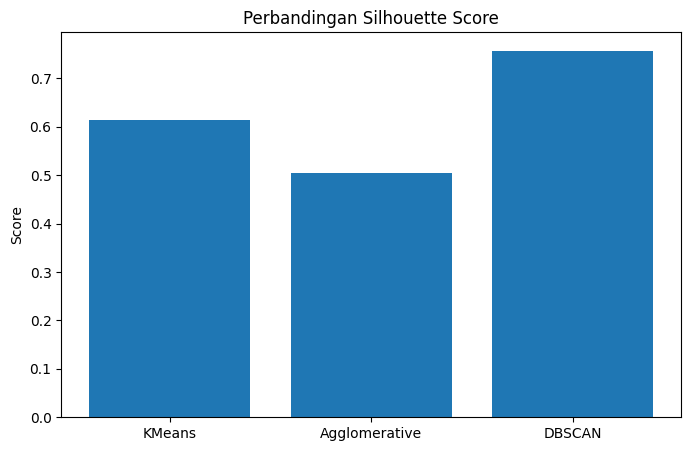

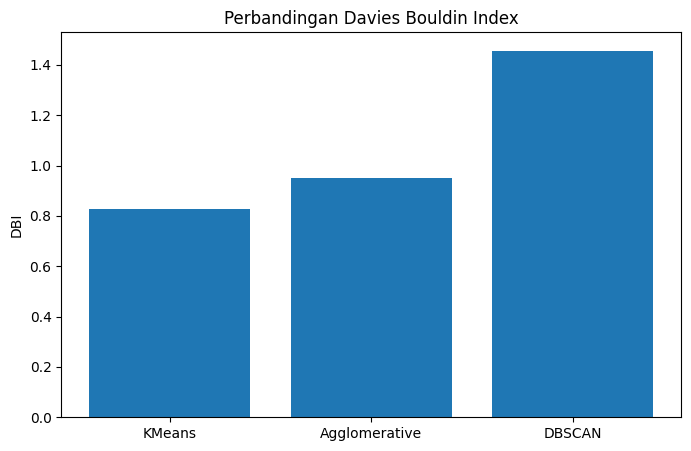

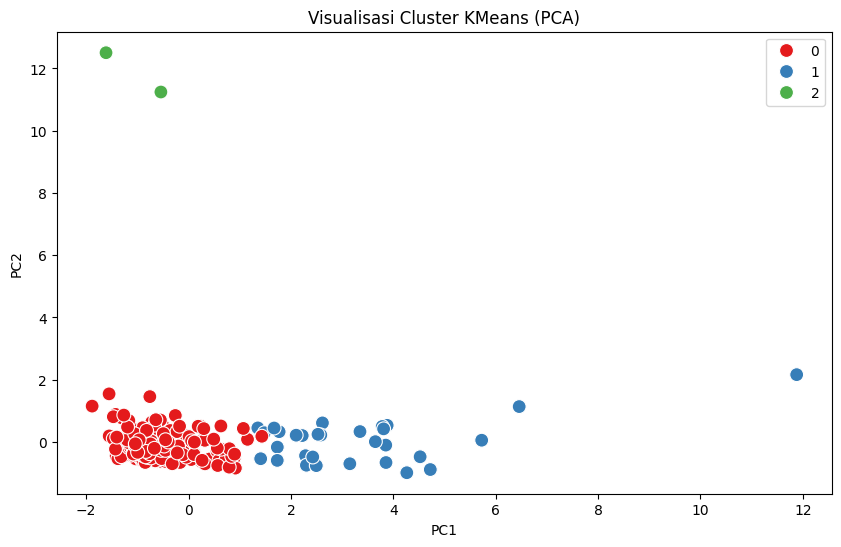

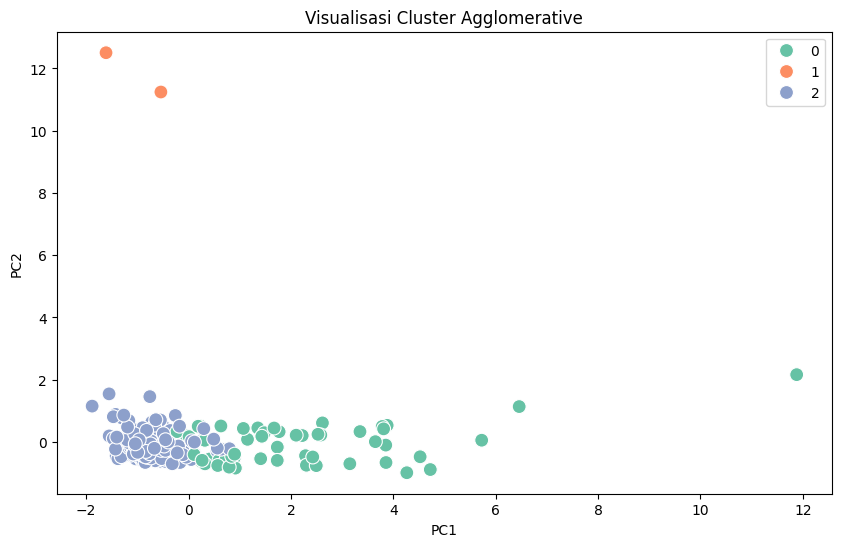

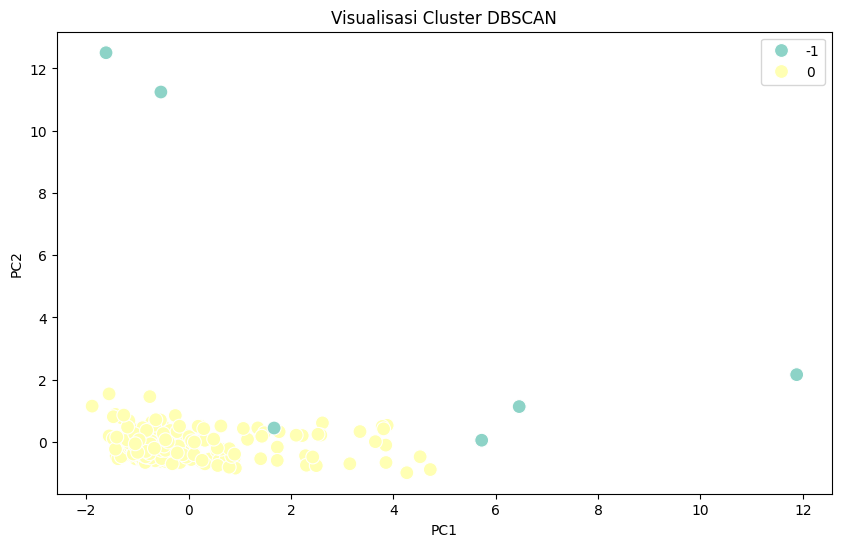


NOISE DBSCAN
Jumlah Noise : 6

KONTRIBUSI PCA
                        PC1       PC2
peminat_2023       0.510282 -0.130929
peminat_2024       0.436544  0.010911
daya_tampung_2024  0.524687  0.106313
daya_tampung_2025  0.512895  0.204380
keketatan         -0.084939  0.701836
pertumbuhan       -0.058907  0.661129

RINGKASAN KMEANS
                peminat_2023  peminat_2024  daya_tampung_2024  \
cluster_kmeans                                                  
0                     404.48        631.30              28.41   
1                    1808.03       2239.17             115.30   
2                      33.50        966.00              33.50   

                daya_tampung_2025  keketatan  pertumbuhan  
cluster_kmeans                                             
0                           29.85       0.12         0.78  
1                          111.83       0.08         0.49  
2                           96.00       2.69        31.24  

KESIMPULAN MODEL
           Model  Silhoue

In [16]:
# ==========================================
# 7. EVALUASI & IMPROVEMENT MODEL CLUSTERING
# ==========================================

# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# ==========================================
# MEMBERSIHKAN NAMA KOLOM
# ==========================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# ==========================================
# DATA CLEANING
# ==========================================
df = df.drop_duplicates()

df = df.fillna(
    df.median(numeric_only=True)
)

# ==========================================
# FITUR CLUSTERING
# ==========================================
fitur = [
    'peminat_2023',
    'peminat_2024',
    'daya_tampung_2024',
    'daya_tampung_2025',
    'keketatan',
    'pertumbuhan'
]

X = df[fitur]

# ==========================================
# NORMALISASI
# ==========================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# PCA UNTUK VISUALISASI
# ==========================================
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

print("===================================")
print("EXPLAINED VARIANCE PCA")
print("===================================")

print(
    pca.explained_variance_ratio_
)

print("\nTotal Variance :")

print(
    pca.explained_variance_ratio_.sum()
)

# ==========================================
# VISUALISASI PCA
# ==========================================
plt.figure(figsize=(10,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2']
)

plt.title("Visualisasi PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# ==========================================
# MODEL KMEANS
# ==========================================
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

# ==========================================
# EVALUASI KMEANS
# ==========================================
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

kmeans_dbi = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

kmeans_chs = calinski_harabasz_score(
    X_scaled,
    kmeans_labels
)

# ==========================================
# MODEL AGGLOMERATIVE
# ==========================================
agglo = AgglomerativeClustering(
    n_clusters=3
)

agglo_labels = agglo.fit_predict(
    X_scaled
)

# ==========================================
# EVALUASI AGGLOMERATIVE
# ==========================================
agglo_silhouette = silhouette_score(
    X_scaled,
    agglo_labels
)

agglo_dbi = davies_bouldin_score(
    X_scaled,
    agglo_labels
)

agglo_chs = calinski_harabasz_score(
    X_scaled,
    agglo_labels
)

# ==========================================
# MODEL DBSCAN
# ==========================================
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

# ==========================================
# HANDLE DBSCAN NOISE
# ==========================================
if len(set(dbscan_labels)) > 1:

    dbscan_silhouette = silhouette_score(
        X_scaled,
        dbscan_labels
    )

    dbscan_dbi = davies_bouldin_score(
        X_scaled,
        dbscan_labels
    )

    dbscan_chs = calinski_harabasz_score(
        X_scaled,
        dbscan_labels
    )

else:

    dbscan_silhouette = np.nan
    dbscan_dbi = np.nan
    dbscan_chs = np.nan

# ==========================================
# TABEL PERBANDINGAN MODEL
# ==========================================
hasil = pd.DataFrame({

    'Model': [
        'KMeans',
        'Agglomerative',
        'DBSCAN'
    ],

    'Silhouette Score': [
        kmeans_silhouette,
        agglo_silhouette,
        dbscan_silhouette
    ],

    'Davies Bouldin Index': [
        kmeans_dbi,
        agglo_dbi,
        dbscan_dbi
    ],

    'Calinski Harabasz Score': [
        kmeans_chs,
        agglo_chs,
        dbscan_chs
    ]
})

print("\n===================================")
print("PERBANDINGAN MODEL")
print("===================================")

print(hasil)

# ==========================================
# VISUALISASI SILHOUETTE
# ==========================================
plt.figure(figsize=(8,5))

plt.bar(
    hasil['Model'],
    hasil['Silhouette Score']
)

plt.title("Perbandingan Silhouette Score")
plt.ylabel("Score")

plt.show()

# ==========================================
# VISUALISASI DBI
# ==========================================
plt.figure(figsize=(8,5))

plt.bar(
    hasil['Model'],
    hasil['Davies Bouldin Index']
)

plt.title("Perbandingan Davies Bouldin Index")
plt.ylabel("DBI")

plt.show()

# ==========================================
# VISUALISASI PCA KMEANS
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=kmeans_labels,
    palette='Set1',
    s=100
)

plt.title("Visualisasi Cluster KMeans (PCA)")

plt.show()

# ==========================================
# VISUALISASI PCA AGGLOMERATIVE
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=agglo_labels,
    palette='Set2',
    s=100
)

plt.title("Visualisasi Cluster Agglomerative")

plt.show()

# ==========================================
# VISUALISASI PCA DBSCAN
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=dbscan_labels,
    palette='Set3',
    s=100
)

plt.title("Visualisasi Cluster DBSCAN")

plt.show()

# ==========================================
# DETEKSI NOISE DBSCAN
# ==========================================
print("\n===================================")
print("NOISE DBSCAN")
print("===================================")

noise = np.sum(dbscan_labels == -1)

print(f"Jumlah Noise : {noise}")

# ==========================================
# FITUR PALING BERPENGARUH
# ==========================================
print("\n===================================")
print("KONTRIBUSI PCA")
print("===================================")

loading = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=fitur
)

print(loading)

# ==========================================
# ANALISIS CLUSTER KMEANS
# ==========================================
df['cluster_kmeans'] = kmeans_labels

summary = df.groupby(
    'cluster_kmeans'
)[fitur].mean().round(2)

print("\n===================================")
print("RINGKASAN KMEANS")
print("===================================")

print(summary)

# ==========================================
# INTERPRETASI MODEL TERBAIK
# ==========================================
print("\n===================================")
print("KESIMPULAN MODEL")
print("===================================")

best_model = hasil.sort_values(
    by='Silhouette Score',
    ascending=False
)

print(best_model)

print("""
INTERPRETASI:

1. Silhouette Score lebih tinggi
   = cluster lebih terpisah

2. Davies Bouldin lebih kecil
   = cluster lebih baik

3. Calinski Harabasz lebih tinggi
   = cluster lebih jelas

4. Jika KMeans terbaik:
   data memiliki pola globular

5. Jika DBSCAN terbaik:
   data memiliki banyak outlier/noise

6. Jika Agglomerative terbaik:
   struktur hierarki lebih cocok
""")

# ==========================================
# SIMPAN HASIL
# ==========================================
hasil.to_csv(
    "evaluasi_model_clustering.csv",
    index=False
)

summary.to_csv(
    "ringkasan_cluster.csv"
)

print("\n===================================")
print("HASIL EVALUASI DISIMPAN")
print("===================================")

RINGKASAN CLUSTER
         peminat_2023  peminat_2024  daya_tampung_2024  daya_tampung_2025  \
cluster                                                                     
0              404.48        631.30              28.41              29.85   
1             1808.03       2239.17             115.30             111.83   
2               33.50        966.00              33.50              96.00   

         keketatan  pertumbuhan  
cluster                          
0             0.12         0.78  
1             0.08         0.49  
2             2.69        31.24  

JUMLAH ANGGOTA
cluster
0    176
1     30
2      2
Name: count, dtype: int64

LABEL CLUSTER

Cluster 0
Kategori : Prodi Niche


Cluster 1
Kategori : Prodi Super Populer


Cluster 2
Kategori : Prodi Menengah



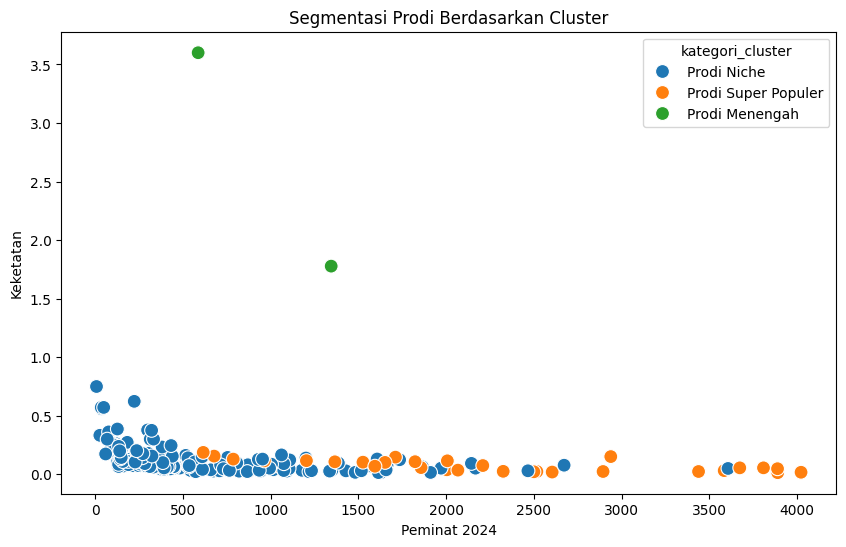


TOP PRODI PALING POPULER
                             prodi univ  peminat_2024  keketatan  \
68                       Psikologi  UGM        4022.0   0.017722   
5                       Kedokteran  UGM        3889.0   0.014073   
93        Administrasi Perkantoran  UNY        3888.0   0.048128   
71   Manajemen Informasi Kesehatan  UGM        3808.0   0.055470   
191            Teknik Pertambangan  UPN        3673.0   0.055396   
87         Akuntansi Sektor Publik  UGM        3606.0   0.050251   
51                           Hukum  UGM        3584.0   0.031851   
106                      Manajemen  UNY        3438.0   0.024251   
179                      Manajemen  UPN        2938.0   0.151611   
153                      Psikologi  UNY        2894.0   0.024229   
107            Manajemen Pemasaran  UNY        2672.0   0.077922   
48                       Manajemen  UGM        2604.0   0.019506   
95                       Akuntansi  UNY        2517.0   0.024308   
102                Ilm

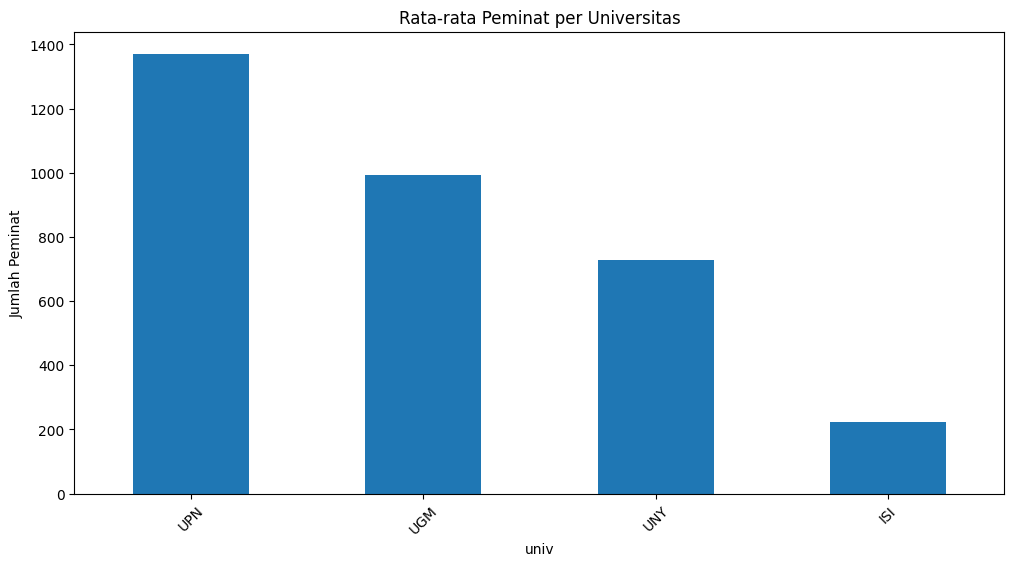


REKOMENDASI STRATEGIS

========== Prodi Niche ==========

Strategi:
- Rebranding program studi
- Evaluasi kebutuhan pasar
- Kolaborasi industri
- Optimalisasi promosi digital
- Pertimbangkan efisiensi kuota


========== Prodi Super Populer ==========

Strategi:
- Tambah daya tampung
- Tingkatkan seleksi
- Perkuat kualitas akademik
- Optimalkan branding
- Antisipasi over capacity


========== Prodi Menengah ==========

Strategi:
- Tingkatkan promosi
- Perkuat kurikulum
- Tingkatkan daya saing
- Evaluasi kuota tahunan


PRODI KRITIS
                         prodi univ  peminat_2024  keketatan  pertumbuhan
118  Pendidikan Bahasa Prancis  UNY          68.0   0.304348    -0.260870
132           Pendidikan Kriya  UNY          36.0   0.560000    -0.280000
196            Konservasi Seni  ISI          27.0   0.333333    -0.550000
199           Pendidikan Musik  ISI          77.0   0.362205    -0.393701
202             Seni Karawitan  ISI          35.0   0.571429     0.000000
204            Sen

In [17]:
# ==========================================
# 8. INSIGHT BISNIS & REKOMENDASI STRATEGIS
# ==========================================

# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# ==========================================
# MEMBERSIHKAN NAMA KOLOM
# ==========================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# ==========================================
# DATA CLEANING
# ==========================================
df = df.drop_duplicates()

df = df.fillna(
    df.median(numeric_only=True)
)

# ==========================================
# FITUR CLUSTERING
# ==========================================
fitur = [
    'peminat_2023',
    'peminat_2024',
    'daya_tampung_2024',
    'daya_tampung_2025',
    'keketatan',
    'pertumbuhan'
]

X = df[fitur]

# ==========================================
# NORMALISASI
# ==========================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# CLUSTERING
# ==========================================
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(
    X_scaled
)

# ==========================================
# RINGKASAN CLUSTER
# ==========================================
cluster_summary = df.groupby(
    'cluster'
)[fitur].mean().round(2)

print("===================================")
print("RINGKASAN CLUSTER")
print("===================================")

print(cluster_summary)

# ==========================================
# JUMLAH ANGGOTA CLUSTER
# ==========================================
print("\n===================================")
print("JUMLAH ANGGOTA")
print("===================================")

print(
    df['cluster']
    .value_counts()
    .sort_index()
)

# ==========================================
# LABELING CLUSTER
# ==========================================
cluster_label = {}

for c in sorted(df['cluster'].unique()):

    rata_peminat = df[
        df['cluster'] == c
    ]['peminat_2024'].mean()

    if rata_peminat > 1500:

        cluster_label[c] = "Prodi Super Populer"

    elif rata_peminat > 700:

        cluster_label[c] = "Prodi Menengah"

    else:

        cluster_label[c] = "Prodi Niche"

# ==========================================
# TAMBAHKAN LABEL
# ==========================================
df['kategori_cluster'] = df['cluster'].map(
    cluster_label
)

# ==========================================
# TAMPILKAN LABEL CLUSTER
# ==========================================
print("\n===================================")
print("LABEL CLUSTER")
print("===================================")

for key, value in cluster_label.items():

    print(f"""
Cluster {key}
Kategori : {value}
""")

# ==========================================
# VISUALISASI CLUSTER
# ==========================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='peminat_2024',
    y='keketatan',
    hue='kategori_cluster',
    s=100
)

plt.title("Segmentasi Prodi Berdasarkan Cluster")
plt.xlabel("Peminat 2024")
plt.ylabel("Keketatan")

plt.show()

# ==========================================
# TOP PRODI PALING POPULER
# ==========================================
print("\n===================================")
print("TOP PRODI PALING POPULER")
print("===================================")

top_populer = df.sort_values(
    by='peminat_2024',
    ascending=False
)

print(
    top_populer[
        [
            'prodi',
            'univ',
            'peminat_2024',
            'keketatan',
            'kategori_cluster'
        ]
    ].head(15)
)

# ==========================================
# TOP PRODI PALING KETAT
# ==========================================
print("\n===================================")
print("TOP PRODI PALING KETAT")
print("===================================")

top_ketat = df.sort_values(
    by='keketatan',
    ascending=True
)

print(
    top_ketat[
        [
            'prodi',
            'univ',
            'keketatan',
            'peminat_2024',
            'kategori_cluster'
        ]
    ].head(15)
)

# ==========================================
# TOP PRODI PERTUMBUHAN TERTINGGI
# ==========================================
print("\n===================================")
print("TOP PERTUMBUHAN TERTINGGI")
print("===================================")

growth = df.sort_values(
    by='pertumbuhan',
    ascending=False
)

print(
    growth[
        [
            'prodi',
            'univ',
            'pertumbuhan',
            'peminat_2023',
            'peminat_2024',
            'kategori_cluster'
        ]
    ].head(15)
)

# ==========================================
# PRODI DENGAN PEMINAT RENDAH
# ==========================================
print("\n===================================")
print("PRODI PEMINAT RENDAH")
print("===================================")

rendah = df.sort_values(
    by='peminat_2024',
    ascending=True
)

print(
    rendah[
        [
            'prodi',
            'univ',
            'peminat_2024',
            'keketatan',
            'kategori_cluster'
        ]
    ].head(15)
)

# ==========================================
# ANALISIS UNIVERSITAS
# ==========================================
print("\n===================================")
print("RATA-RATA PEMINAT PER UNIVERSITAS")
print("===================================")

univ_summary = df.groupby(
    'univ'
)[
    [
        'peminat_2024',
        'keketatan',
        'pertumbuhan'
    ]
].mean().round(2)

print(
    univ_summary.sort_values(
        by='peminat_2024',
        ascending=False
    )
)

# ==========================================
# VISUALISASI UNIVERSITAS
# ==========================================
plt.figure(figsize=(12,6))

univ_summary[
    'peminat_2024'
].sort_values(
    ascending=False
).plot(kind='bar')

plt.title("Rata-rata Peminat per Universitas")
plt.ylabel("Jumlah Peminat")

plt.xticks(rotation=45)

plt.show()

# ==========================================
# STRATEGI TIAP CLUSTER
# ==========================================
print("\n===================================")
print("REKOMENDASI STRATEGIS")
print("===================================")

for c in sorted(df['cluster'].unique()):

    kategori = cluster_label[c]

    print(f"\n========== {kategori} ==========")

    if kategori == "Prodi Super Populer":

        print("""
Strategi:
- Tambah daya tampung
- Tingkatkan seleksi
- Perkuat kualitas akademik
- Optimalkan branding
- Antisipasi over capacity
""")

    elif kategori == "Prodi Menengah":

        print("""
Strategi:
- Tingkatkan promosi
- Perkuat kurikulum
- Tingkatkan daya saing
- Evaluasi kuota tahunan
""")

    else:

        print("""
Strategi:
- Rebranding program studi
- Evaluasi kebutuhan pasar
- Kolaborasi industri
- Optimalisasi promosi digital
- Pertimbangkan efisiensi kuota
""")

# ==========================================
# DETEKSI PRODI KRITIS
# ==========================================
print("\n===================================")
print("PRODI KRITIS")
print("===================================")

kritis = df[
    (df['peminat_2024'] < 100) &
    (df['keketatan'] > 0.3)
]

print(
    kritis[
        [
            'prodi',
            'univ',
            'peminat_2024',
            'keketatan',
            'pertumbuhan'
        ]
    ]
)

# ==========================================
# DETEKSI PRODI POTENSIAL
# ==========================================
print("\n===================================")
print("PRODI POTENSIAL")
print("===================================")

potensial = df[
    (df['pertumbuhan'] > 1.2) &
    (df['peminat_2024'] > 500)
]

print(
    potensial[
        [
            'prodi',
            'univ',
            'pertumbuhan',
            'peminat_2024',
            'kategori_cluster'
        ]
    ].sort_values(
        by='pertumbuhan',
        ascending=False
    )
)

# ==========================================
# SIMPAN HASIL AKHIR
# ==========================================
df.to_csv(
    "hasil_final_analisis.csv",
    index=False
)

print("\n===================================")
print("HASIL FINAL BERHASIL DISIMPAN")
print("===================================")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 55.3 MB/s eta 0:00:00


2026-05-15 21:08:41.744 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 21:08:41.852 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-15 21:08:41.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 21:08:41.855 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 21:08:41.860 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 21:08:41.861 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 21:08:41.863 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 21:08:41.865 Thread 'MainThread': mi

DeltaGenerator()

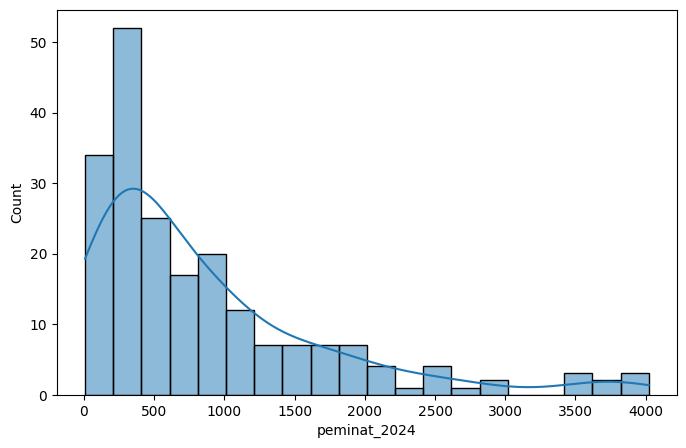

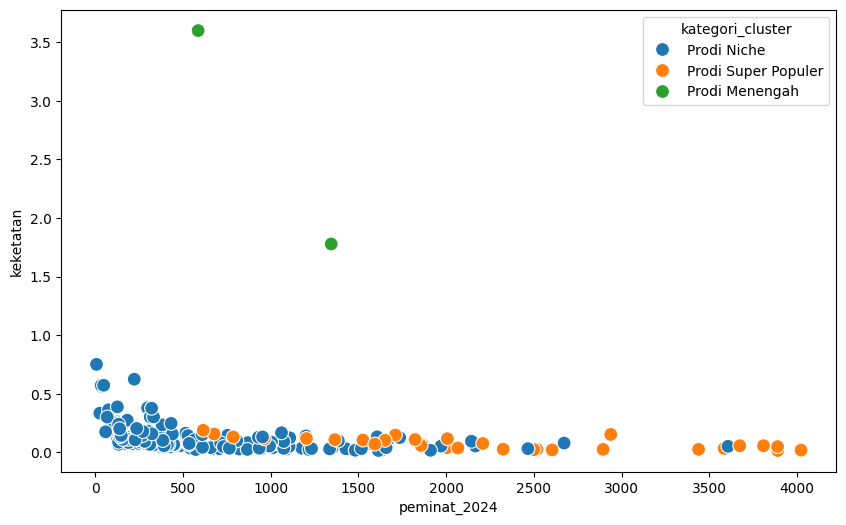

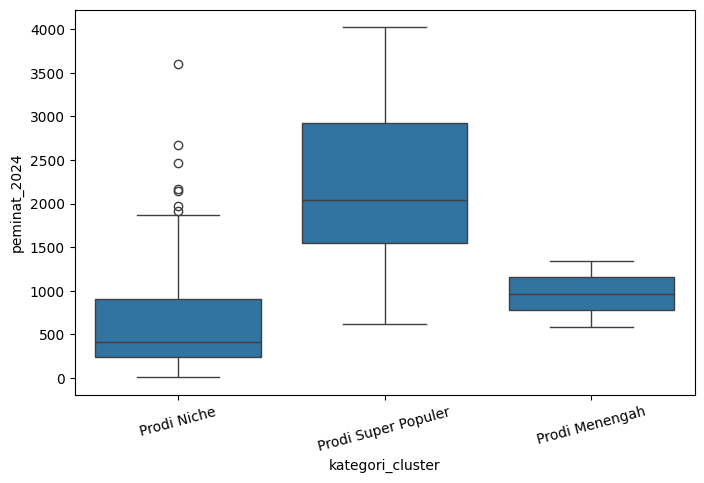

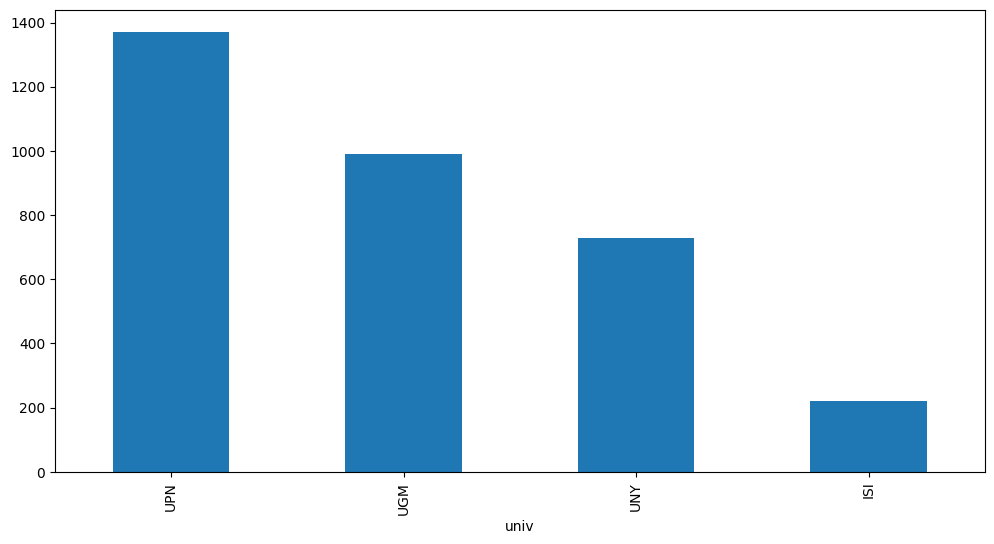

In [20]:
# ==========================================
# 10. DEPLOYMENT ANALYTICS DASHBOARD
# ==========================================
# Dashboard sederhana untuk eksplorasi hasil
# clustering & prediksi menggunakan Streamlit
# ==========================================

# ==========================================
# INSTALL STREAMLIT
# ==========================================
# jalankan di terminal / cmd:
# pip install streamlit

# ==========================================
# IMPORT LIBRARY
# ==========================================
!pip install streamlit
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_csv("hasil_final_analisis.csv")

# ==========================================
# TITLE
# ==========================================
st.title("Dashboard Analisis Prodi")

# ==========================================
# SIDEBAR FILTER
# ==========================================
st.sidebar.header("Filter")

univ_filter = st.sidebar.multiselect(
    "Pilih Universitas",
    options=df['univ'].unique(),
    default=df['univ'].unique()
)

cluster_filter = st.sidebar.multiselect(
    "Pilih Cluster",
    options=df['cluster'].unique(),
    default=df['cluster'].unique()
)

# ==========================================
# FILTER DATA
# ==========================================
filtered_df = df[
    (df['univ'].isin(univ_filter)) &
    (df['cluster'].isin(cluster_filter))
]

# ==========================================
# TAMPILKAN DATA
# ==========================================
st.subheader("Dataset")

st.dataframe(filtered_df)

# ==========================================
# METRIC
# ==========================================
st.subheader("Ringkasan")

col1, col2, col3 = st.columns(3)

col1.metric(
    "Jumlah Prodi",
    filtered_df.shape[0]
)

col2.metric(
    "Rata-rata Peminat 2024",
    round(filtered_df['peminat_2024'].mean(), 2)
)

col3.metric(
    "Rata-rata Keketatan",
    round(filtered_df['keketatan'].mean(), 4)
)

# ==========================================
# DISTRIBUSI PEMINAT
# ==========================================
st.subheader("Distribusi Peminat 2024")

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(
    filtered_df['peminat_2024'],
    bins=20,
    kde=True,
    ax=ax
)

st.pyplot(fig)

# ==========================================
# CLUSTER VISUALIZATION
# ==========================================
st.subheader("Visualisasi Cluster")

fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(
    data=filtered_df,
    x='peminat_2024',
    y='keketatan',
    hue='kategori_cluster',
    s=100,
    ax=ax
)

st.pyplot(fig)

# ==========================================
# TOP PRODI POPULER
# ==========================================
st.subheader("Top Prodi Populer")

top_populer = filtered_df.sort_values(
    by='peminat_2024',
    ascending=False
)

st.dataframe(
    top_populer[
        [
            'prodi',
            'univ',
            'peminat_2024',
            'keketatan'
        ]
    ].head(10)
)

# ==========================================
# TOP PERTUMBUHAN
# ==========================================
st.subheader("Top Pertumbuhan")

top_growth = filtered_df.sort_values(
    by='pertumbuhan',
    ascending=False
)

st.dataframe(
    top_growth[
        [
            'prodi',
            'univ',
            'pertumbuhan'
        ]
    ].head(10)
)

# ==========================================
# BOXPLOT CLUSTER
# ==========================================
st.subheader("Boxplot Peminat per Cluster")

fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(
    data=filtered_df,
    x='kategori_cluster',
    y='peminat_2024',
    ax=ax
)

plt.xticks(rotation=15)

st.pyplot(fig)

# ==========================================
# RATA-RATA UNIVERSITAS
# ==========================================
st.subheader("Rata-rata Peminat per Universitas")

univ_mean = filtered_df.groupby(
    'univ'
)['peminat_2024'].mean().sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(12,6))

univ_mean.plot(
    kind='bar',
    ax=ax
)

st.pyplot(fig)

# ==========================================
# DOWNLOAD DATA
# ==========================================
st.subheader("Download Hasil")

csv = filtered_df.to_csv(index=False)

st.download_button(
    label="Download CSV",
    data=csv,
    file_name='hasil_filter.csv',
    mime='text/csv'
)

# ==========================================
# FOOTER
# ==========================================
st.markdown("""
---
Dashboard Analisis Prodi
Machine Learning Clustering & Prediction
""")

JUMLAH DATA
(180, 8)

SIMILARITY MATRIX
prodi                              Biologi   Farmasi  Geografi Lingkungan  \
prodi                                                                       
Biologi                           1.000000  0.819106             0.973937   
Farmasi                           0.819106  1.000000             0.925927   
Geografi Lingkungan               0.973937  0.925927             1.000000   
Kartografi Dan Penginderaan Jauh  0.973159  0.887566             0.989555   
Pembangunan Wilayah               0.967998  0.920594             0.997032   

prodi                             Kartografi Dan Penginderaan Jauh  \
prodi                                                                
Biologi                                                   0.973159   
Farmasi                                                   0.887566   
Geografi Lingkungan                                       0.989555   
Kartografi Dan Penginderaan Jauh                          1.000000   


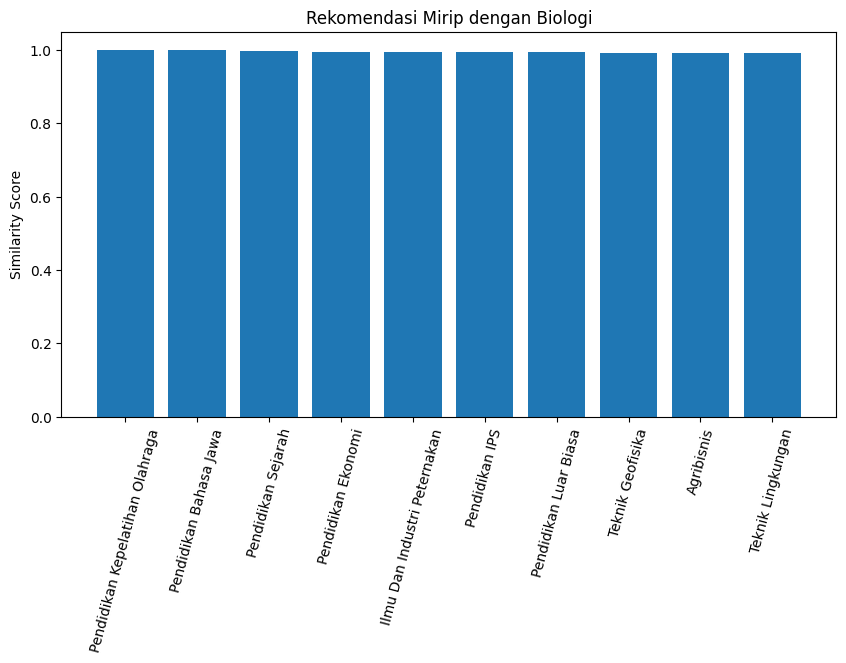


REKOMENDASI BERDASARKAN FILTER
                                                 prodi univ  peminat_2024  \
92                            Administrasi Perkantoran  UNY        3888.0   
71                       Manajemen Informasi Kesehatan  UGM        3808.0   
87                             Akuntansi Sektor Publik  UGM        3606.0   
98                                 Manajemen Pemasaran  UNY        2672.0   
143                                          Tata Boga  UNY        2466.0   
72                  Teknologi Rekayasa Perangkat Lunak  UGM        2167.0   
86                                           Perbankan  UGM        2144.0   
90                                      Bahasa Inggris  UGM        1971.0   
91                            Bisnis Perjalanan Wisata  UGM        1865.0   
85                    Manajemen Dan Penilaian Properti  UGM        1663.0   
88                     Pembangunan Ekonomi Kewilayahan  UGM        1607.0   
76   Teknik Pengelolaan Dan Pemeliharaan Inf

In [23]:
# ==========================================
# AI RECOMMENDATION SYSTEM (FIX VERSION)
# TANPA ERROR DUPLICATE PRODI
# ==========================================

# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# ==========================================
# CLEAN COLUMN
# ==========================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# ==========================================
# CLEAN DATA
# ==========================================
df = df.drop_duplicates()

df = df.fillna(
    df.median(numeric_only=True)
)

# ==========================================
# HAPUS DUPLIKAT PRODI
# ==========================================
df = df.drop_duplicates(
    subset='prodi'
).reset_index(drop=True)

# ==========================================
# CEK DATA
# ==========================================
print("===================================")
print("JUMLAH DATA")
print("===================================")

print(df.shape)

# ==========================================
# FITUR REKOMENDASI
# ==========================================
fitur = [
    'peminat_2024',
    'keketatan',
    'pertumbuhan',
    'daya_tampung_2025'
]

# ==========================================
# NORMALISASI
# ==========================================
scaler = MinMaxScaler()

X = scaler.fit_transform(
    df[fitur]
)

# ==========================================
# COSINE SIMILARITY
# ==========================================
similarity_matrix = cosine_similarity(X)

# ==========================================
# SIMILARITY DATAFRAME
# ==========================================
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df['prodi'],
    columns=df['prodi']
)

# ==========================================
# CEK MATRIX
# ==========================================
print("\n===================================")
print("SIMILARITY MATRIX")
print("===================================")

print(similarity_df.iloc[:5, :5])

# ==========================================
# FUNCTION REKOMENDASI
# ==========================================
def rekomendasi_prodi(
    nama_prodi,
    top_n=5
):

    print("\n===================================")
    print("SISTEM REKOMENDASI")
    print("===================================")

    # ======================================
    # VALIDASI
    # ======================================
    if nama_prodi not in similarity_df.index:

        print(f"""
Prodi '{nama_prodi}' tidak ditemukan
""")

        return

    # ======================================
    # AMBIL SIMILARITY SCORE
    # ======================================
    similarity_score = similarity_df.loc[
        nama_prodi
    ]

    # ======================================
    # SORTING
    # ======================================
    similarity_score = similarity_score.sort_values(
        ascending=False
    )

    # ======================================
    # HAPUS DIRI SENDIRI
    # ======================================
    similarity_score = similarity_score.iloc[1:]

    # ======================================
    # AMBIL TOP N
    # ======================================
    top_rekomendasi = similarity_score.head(
        top_n
    )

    # ======================================
    # FILTER DATA
    # ======================================
    hasil = df[
        df['prodi'].isin(
            top_rekomendasi.index
        )
    ][
        [
            'prodi',
            'univ',
            'peminat_2024',
            'keketatan',
            'pertumbuhan',
            'daya_tampung_2025'
        ]
    ].copy()

    # ======================================
    # TAMBAH SCORE
    # ======================================
    hasil['similarity_score'] = (
        hasil['prodi']
        .map(top_rekomendasi)
    )

    # ======================================
    # SORT FINAL
    # ======================================
    hasil = hasil.sort_values(
        by='similarity_score',
        ascending=False
    )

    # ======================================
    # OUTPUT
    # ======================================
    print(f"""
PRODI ACUAN:
{nama_prodi}
""")

    print("TOP REKOMENDASI:")

    print(hasil)

    # ======================================
    # VISUALISASI
    # ======================================
    plt.figure(figsize=(10,5))

    plt.bar(
        hasil['prodi'],
        hasil['similarity_score']
    )

    plt.title(
        f"Rekomendasi Mirip dengan {nama_prodi}"
    )

    plt.ylabel("Similarity Score")

    plt.xticks(rotation=75)

    plt.show()

# ==========================================
# CONTOH PENGGUNAAN
# ==========================================

# gunakan salah satu prodi dari dataset
contoh_prodi = df['prodi'].iloc[0]

rekomendasi_prodi(
    nama_prodi=contoh_prodi,
    top_n=10
)

# ==========================================
# REKOMENDASI BERDASARKAN FILTER
# ==========================================
def rekomendasi_filter(
    min_peminat=500,
    max_keketatan=0.20,
    min_pertumbuhan=1.0
):

    hasil = df[
        (
            df['peminat_2024'] >= min_peminat
        )
        &
        (
            df['keketatan'] <= max_keketatan
        )
        &
        (
            df['pertumbuhan'] >= min_pertumbuhan
        )
    ]

    hasil = hasil.sort_values(
        by='peminat_2024',
        ascending=False
    )

    print("\n===================================")
    print("REKOMENDASI BERDASARKAN FILTER")
    print("===================================")

    print(hasil[
        [
            'prodi',
            'univ',
            'peminat_2024',
            'keketatan',
            'pertumbuhan'
        ]
    ])

    return hasil

# ==========================================
# CONTOH FILTER
# ==========================================
rekomendasi_filter(
    min_peminat=1000,
    max_keketatan=0.15,
    min_pertumbuhan=1.05
)

# ==========================================
# SAVE RESULT
# ==========================================
df.to_csv(
    "recommendation_system_fixed.csv",
    index=False
)

print("\n===================================")
print("FILE BERHASIL DISIMPAN")
print("===================================")

PROFIL PREFERENSI USER

Minat Prodi Populer : True
Suka Persaingan     : False
Ingin Pertumbuhan   : True
Kapasitas Besar     : True


TOP REKOMENDASI PRODI
                                            prodi univ  peminat_2024  \
80                            Teknologi Veteriner  UGM         755.0   
74   Teknologi Rekayasa Instrumentasi Dan Kontrol  UGM         529.0   
82            Teknologi Survei Dan Pemetaan Dasar  UGM         568.0   
81               Pengembangan Produk Agroindustri  UGM        1201.0   
73                     Teknologi Rekayasa Elektro  UGM        1109.0   
77                       Teknologi Rekayasa Mesin  UGM         929.0   
78    Teknik Pengelolaan Dan Perawatan Alat Berat  UGM         788.0   
41                                   Higiene Gigi  UGM         300.0   
88                Pembangunan Ekonomi Kewilayahan  UGM        1607.0   
145                      Tata Rias dan Kecantikan  UNY        1005.0   

     keketatan  pertumbuhan  daya_tampung_2025  re

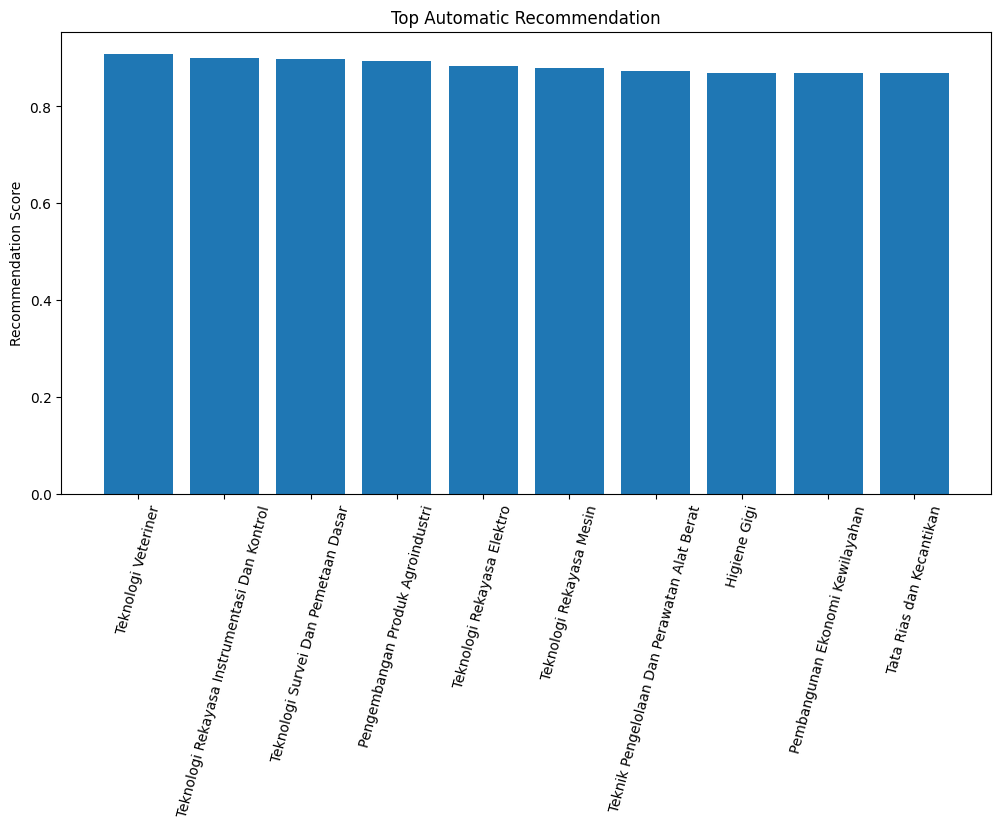


SIMULASI TIPE USER

===== USER AMBISIUS =====
PROFIL PREFERENSI USER

Minat Prodi Populer : True
Suka Persaingan     : True
Ingin Pertumbuhan   : True
Kapasitas Besar     : False


TOP REKOMENDASI PRODI
                                   prodi univ  peminat_2024  keketatan  \
139           Pengelolaan Usaha Rekreasi  UNY         382.0   0.233333   
21   Penyuluhan Dan Komunikasi Pertanian  UGM         162.0   0.071429   
140     Pengobatan Tradisional Indonesia  UNY         299.0   0.378378   
164                       Etnomusikologi  ISI        1345.0   1.777778   
141                    Promosi Kesehatan  UNY         807.0   0.097561   

     pertumbuhan  daya_tampung_2025  recommendation_score  
139     5.366667               14.0              0.991491  
21      0.285714                9.0              0.949114  
140     7.081081               14.0              0.935985  
164    48.814815               48.0              0.929033  
141     5.560976               12.0              0.

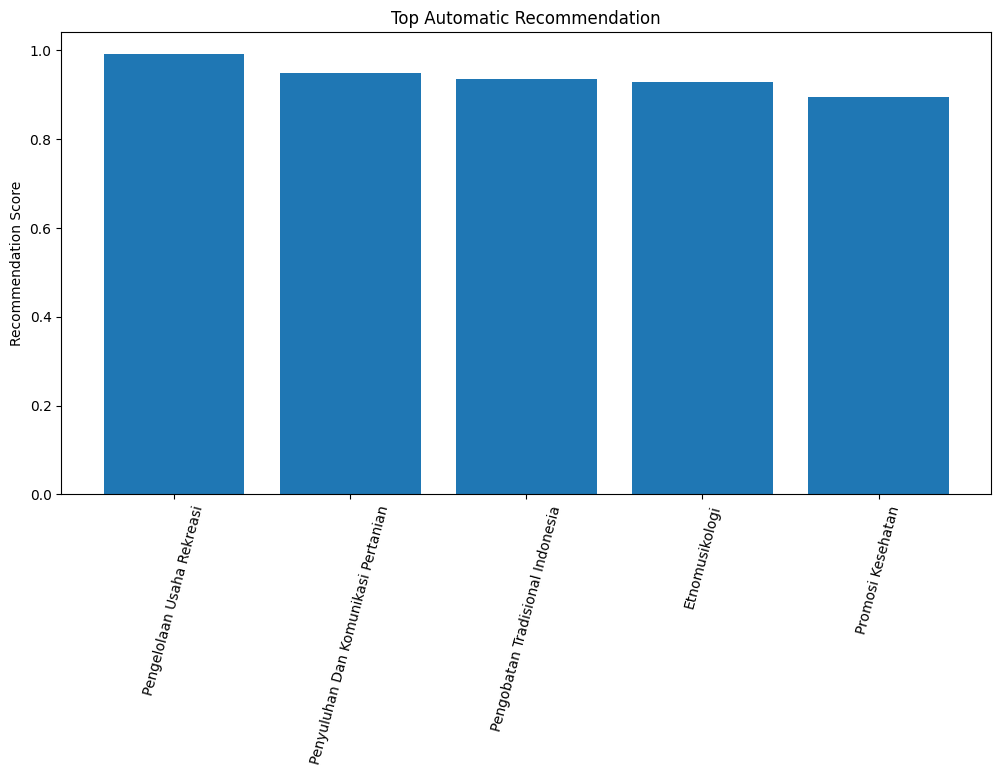


===== USER MAIN AMAN =====
PROFIL PREFERENSI USER

Minat Prodi Populer : False
Suka Persaingan     : False
Ingin Pertumbuhan   : True
Kapasitas Besar     : True


TOP REKOMENDASI PRODI
                                prodi univ  peminat_2024  keketatan  \
11                              Kimia  UGM         414.0   0.167286   
0                             Biologi  UGM         516.0   0.161905   
3    Kartografi Dan Penginderaan Jauh  UGM         346.0   0.107914   
118   Pendidikan Kepelatihan Olahraga  UNY         440.0   0.154639   
142                  Sastra Indonesia  UNY         386.0   0.100559   

     pertumbuhan  daya_tampung_2025  recommendation_score  
11      0.539033               45.0              0.750741  
0       0.228571               68.0              0.744704  
3       0.244604               30.0              0.743192  
118     0.134021               60.0              0.743143  
142     0.078212               36.0              0.740910  


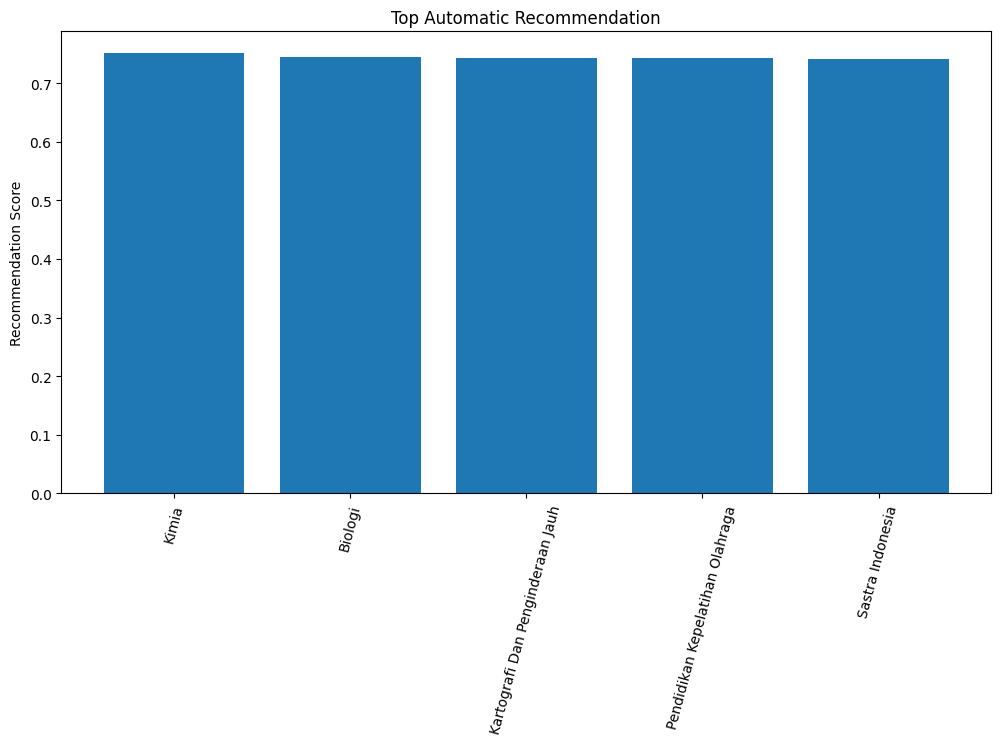


===== USER CARI PELUANG =====
PROFIL PREFERENSI USER

Minat Prodi Populer : False
Suka Persaingan     : False
Ingin Pertumbuhan   : False
Kapasitas Besar     : True


TOP REKOMENDASI PRODI
                               prodi univ  peminat_2024  keketatan  \
149                       Agribisnis  UPN         678.0   0.155772   
26      Ilmu Dan Industri Peternakan  UGM         694.0   0.125523   
0                            Biologi  UGM         516.0   0.161905   
159                Teknik Lingkungan  UPN         954.0   0.130208   
118  Pendidikan Kepelatihan Olahraga  UNY         440.0   0.154639   

     pertumbuhan  daya_tampung_2025  recommendation_score  
149    -0.057024              112.0              0.965035  
26     -0.032078               90.0              0.964926  
0       0.228571               68.0              0.962545  
159     0.242188              100.0              0.960452  
118     0.134021               60.0              0.960296  


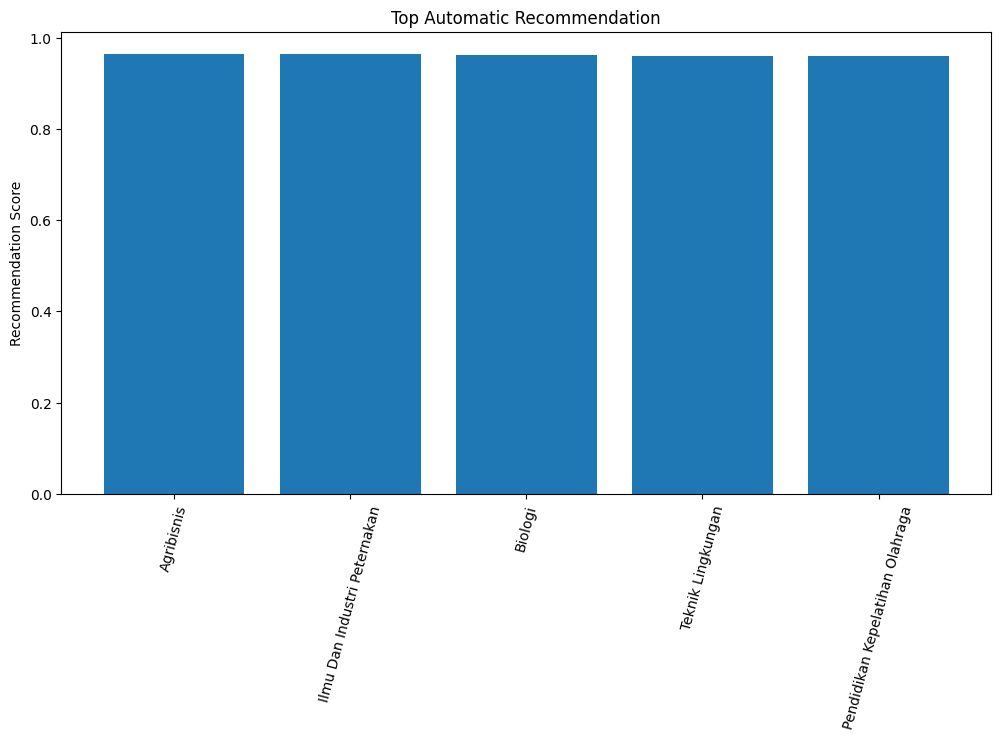


FILE REKOMENDASI DISIMPAN


In [3]:
# ==========================================
# SMART ADMISSION ANALYZER
# ANALISIS PELUANG MASUK PTN & PRODI
# ==========================================
#
# USER INPUT:
# - Nama PTN
# - Nama Prodi
#
# OUTPUT:
# - Kategori peluang masuk
# - Analisis peminat
# - Analisis pertumbuhan
# - Analisis daya tampung
# - Tingkat keketatan
# - Rekomendasi strategi
#
# ==========================================

# ==========================================
# IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# LOAD DATA
# ==========================================
df = pd.read_excel("YANG BENER.xlsx")

# ==========================================
# CLEAN COLUMN
# ==========================================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# ==========================================
# CLEAN DATA
# ==========================================
df = df.drop_duplicates()

df = df.fillna(
    df.median(numeric_only=True)
)

# ==========================================
# CEK NAMA KOLOM
# ==========================================
print("KOLOM DATA:")
print(df.columns)

# ==========================================
# HITUNG PERTUMBUHAN
# ==========================================
df['growth_ratio'] = (
    df['peminat_2024']
    /
    df['peminat_2023']
)

# ==========================================
# HITUNG KEKETATAN
# ==========================================
df['tingkat_keketatan'] = (
    df['daya_tampung_2025']
    /
    df['peminat_2024']
)

# ==========================================
# KATEGORI PELUANG
# ==========================================
def kategori_peluang(row):

    peminat = row['peminat_2024']

    growth = row['growth_ratio']

    keketatan = row['tingkat_keketatan']

    # ======================================
    # SUPER KETAT
    # ======================================
    if (
        peminat > 2000
        and growth > 1.10
        and keketatan < 0.10
    ):

        return "SUPER KETAT"

    # ======================================
    # KETAT
    # ======================================
    elif (
        peminat > 1000
        and growth > 1.00
        and keketatan < 0.20
    ):

        return "KETAT"

    # ======================================
    # SEDANG
    # ======================================
    elif (
        peminat > 500
        and keketatan < 0.35
    ):

        return "SEDANG"

    # ======================================
    # AMAN
    # ======================================
    else:

        return "AMAN"

# ==========================================
# TAMBAH KATEGORI
# ==========================================
df['kategori_peluang'] = df.apply(
    kategori_peluang,
    axis=1
)

# ==========================================
# FUNCTION ANALISIS USER
# ==========================================
def analisis_prodi():

    print("\n===================================")
    print("SMART PTN ANALYZER")
    print("===================================")

    # ======================================
    # INPUT USER
    # ======================================
    ptn = input(
        "Masukkan nama PTN: "
    ).upper()

    prodi = input(
        "Masukkan nama Prodi: "
    ).upper()

    # ======================================
    # FILTER DATA
    # ======================================
    hasil = df[
        (
            df['univ']
            .astype(str)
            .str.upper()
            .str.contains(ptn)
        )
        &
        (
            df['prodi']
            .astype(str)
            .str.upper()
            .str.contains(prodi)
        )
    ]

    # ======================================
    # JIKA TIDAK ADA
    # ======================================
    if hasil.empty:

        print("\nData tidak ditemukan")
        return

    # ======================================
    # AMBIL DATA
    # ======================================
    row = hasil.iloc[0]

    # ======================================
    # OUTPUT ANALISIS
    # ======================================
    print("\n===================================")
    print("HASIL ANALISIS")
    print("===================================")

    print(f"""
PTN                     : {row['univ']}
PRODI                   : {row['prodi']}

PEMINAT 2023            : {row['peminat_2023']}
PEMINAT 2024            : {row['peminat_2024']}

DAYA TAMPUNG 2024       : {row['daya_tampung_2024']}
DAYA TAMPUNG 2025       : {row['daya_tampung_2025']}

PERTUMBUHAN PEMINAT     : {row['growth_ratio']:.2f}x

TINGKAT KEKETATAN       : {row['tingkat_keketatan']:.4f}

KATEGORI PELUANG        : {row['kategori_peluang']}
""")

    # ======================================
    # INTERPRETASI
    # ======================================
    print("\n===================================")
    print("INTERPRETASI")
    print("===================================")

    kategori = row['kategori_peluang']

    if kategori == "SUPER KETAT":

        print("""
- Persaingan sangat tinggi
- Peminat terus meningkat
- Daya tampung sangat terbatas
- Perlu strategi belajar maksimal
- Disarankan punya pilihan cadangan
""")

    elif kategori == "KETAT":

        print("""
- Persaingan cukup tinggi
- Prodi sangat diminati
- Peluang masuk masih realistis
- Perlu persiapan akademik kuat
""")

    elif kategori == "SEDANG":

        print("""
- Persaingan relatif stabil
- Peluang masuk cukup baik
- Cocok untuk strategi realistis
""")

    else:

        print("""
- Persaingan relatif aman
- Daya tampung cukup besar
- Peluang masuk cukup tinggi
""")

    # ======================================
    # REKOMENDASI MIRIP
    # ======================================
    print("\n===================================")
    print("REKOMENDASI ALTERNATIF")
    print("===================================")

    alternatif = df[
        (
            df['kategori_peluang']
            == row['kategori_peluang']
        )
    ]

    alternatif = alternatif.sort_values(
        by='tingkat_keketatan'
    )

    print(
        alternatif[
            [
                'univ',
                'prodi',
                'kategori_peluang',
                'peminat_2024',
                'tingkat_keketatan'
            ]
        ].head(10)
    )

# ==========================================
# JALANKAN SISTEM
# ==========================================
analisis_prodi()

KOLOM DATA:
Index(['prodi', 'univ', 'peminat_2023', 'peminat_2024', 'daya_tampung_2024',
       'daya_tampung_2025', 'keketatan', 'pertumbuhan'],
      dtype='object')

SMART PTN ANALYZER
Masukkan nama PTN: UGM
Masukkan nama Prodi: Manajemen

HASIL ANALISIS

PTN                     : UGM
PRODI                   : Manajemen Sumberdaya Akuatik

PEMINAT 2023            : 167.0
PEMINAT 2024            : 273.0

DAYA TAMPUNG 2024       : 23.0
DAYA TAMPUNG 2025       : 23.0

PERTUMBUHAN PEMINAT     : 1.63x

TINGKAT KEKETATAN       : 0.0842

KATEGORI PELUANG        : AMAN


INTERPRETASI

- Persaingan relatif aman
- Daya tampung cukup besar
- Peluang masuk cukup tinggi


REKOMENDASI ALTERNATIF
    univ                                prodi kategori_peluang  peminat_2024  \
150  UNY           Pengelolaan Usaha Rekreasi             AMAN         382.0   
35   UGM                        Teknik Nuklir             AMAN         377.0   
45   UGM                      Teknik Biomedis             AMAN    